# Blind Reference Database Augmentation Experiment

This notebook systematically evaluates how **blind augmentation** of the reference database affects face recognition performance across different similarity thresholds and sample sizes.

**Experiment Goals:**
- Evaluate augmentation across multiple similarity thresholds (0.1, 0.25, 0.3, 0.4, 0.6, 0.8, 1.0)
- Test different sample sizes for augmentation (0, 10, 30, 50, 100, 200, 300)
- Compute comprehensive metrics: F-beta, Precision, Recall, ROC-AUC, PR-AUC, MCC, Cohen's Kappa, Confusion Matrices
- Identify the optimal (threshold, sample_size) combination for deployment
- Analyze the trade-off between augmentation aggressiveness and recognition quality

In [1]:
import datetime
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import copy
import random
import pickle
import math
import warnings
warnings.filterwarnings('ignore')

# InsightFace imports
from insightface.app import FaceAnalysis
import onnxruntime as ort

# Sklearn imports
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, fbeta_score,
    precision_recall_curve, roc_curve, auc as sk_auc, roc_auc_score,
    matthews_corrcoef, cohen_kappa_score, confusion_matrix
)

BASE_DIR = Path("/app")
TRAINSET_PATH = BASE_DIR / "testsets/four-people-trainset.json"
REFERENCES_PATH = BASE_DIR / "data/references.json"
OUTPUT_ROOT = BASE_DIR / "image_outputs"

# Create experiment output directory
EXPERIMENT_DIR = OUTPUT_ROOT / f"blind_augmentation_exp_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

DET_SIZE = (640, 640)

# ═══════════════════════════════════════════════════════════════
# EXPERIMENT PARAMETERS
# ═══════════════════════════════════════════════════════════════

# Augmentation thresholds to iterate over
AUGMENTATION_THRESHOLDS = [0.1, 0.25, 0.3, 0.4, 0.6, 0.8, 1.0]

# Face identification threshold (used during evaluation)
FACE_IDENTIFICATION_THRESHOLD = 0.30

# F-beta score parameter (< 1 emphasizes precision, > 1 emphasizes recall)
F1_BETA = 0.4

# Fixed recall/precision levels for P@R and R@P metrics
FIXED_RECALL_LEVEL = 0.95
FIXED_PRECISION_LEVEL = 0.95

# Sampling iterations configuration
SAMPLE_SIZES = [0, 10, 30, 50, 100, 200, 300]

# Random seed for reproducibility
RANDOM_SEED = 42

print(f"✓ Setup complete")
print(f"\nPaths:")
print(f"  Output directory: {EXPERIMENT_DIR}")
print(f"  Training set: {TRAINSET_PATH}")
print(f"  References: {REFERENCES_PATH}")
print(f"\nExperiment Configuration:")
print(f"  Augmentation thresholds: {AUGMENTATION_THRESHOLDS}")
print(f"  Sample sizes: {SAMPLE_SIZES}")
print(f"  Total experiment combinations: {len(AUGMENTATION_THRESHOLDS)} thresholds × {len(SAMPLE_SIZES)} sample sizes = {len(AUGMENTATION_THRESHOLDS) * len(SAMPLE_SIZES)}")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Face identification threshold: {FACE_IDENTIFICATION_THRESHOLD}")
print(f"  F-beta parameter: {F1_BETA}")
print(f"  Fixed recall level: {FIXED_RECALL_LEVEL}")
print(f"  Fixed precision level: {FIXED_PRECISION_LEVEL}")

✓ Setup complete

Paths:
  Output directory: /app/image_outputs/blind_augmentation_exp_20260221_235304
  Training set: /app/testsets/four-people-trainset.json
  References: /app/data/references.json

Experiment Configuration:
  Augmentation thresholds: [0.1, 0.25, 0.3, 0.4, 0.6, 0.8, 1.0]
  Sample sizes: [0, 10, 30, 50, 100, 200, 300]
  Total experiment combinations: 7 thresholds × 7 sample sizes = 49
  Random seed: 42
  Face identification threshold: 0.3
  F-beta parameter: 0.4
  Fixed recall level: 0.95
  Fixed precision level: 0.95


## Load Training Set

Load the training dataset and prepare for evaluation.

In [2]:
# Load training set
with open(TRAINSET_PATH, "r", encoding="utf-8") as f:
    train_items = json.load(f)

print(f"✓ Loaded {len(train_items)} training images")

# Analyze training set distribution
label_counts = Counter()
for item in train_items:
    labels = item.get("labels", [])
    for label in labels:
        label_counts[label] += 1

print(f"\nTraining set label distribution:")
for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {label}: {count} images")

✓ Loaded 1536 training images

Training set label distribution:
  Lionel Messi: 369 images
  Donald Trump: 351 images
  Giorgia Meloni: 350 images
  Hugh Jackman: 304 images
  None: 228 images


## Load Precomputed Embeddings

Load precomputed face embeddings to skip expensive face detection and embedding extraction during experiments.

In [3]:
# Load precomputed face embeddings
EMBEDDINGS_PATH = BASE_DIR / "notebooks/data/face_embeddings_20260131_153514.json"

with open(EMBEDDINGS_PATH, "r", encoding="utf-8") as f:
    embeddings_data = json.load(f)

print(f"✓ Loaded precomputed embeddings from {EMBEDDINGS_PATH.name}")
print(f"  Total entries: {len(embeddings_data)}")

# Create a mapping from image path to embeddings for fast lookup
image_to_embeddings = {}
skipped_null_embeddings = 0

for item in embeddings_data:
    image_path = item.get("image_path")
    if not image_path:
        continue
    
    # Skip entries with null embeddings (no faces detected)
    if item.get("embedding") is None:
        skipped_null_embeddings += 1
        continue
    
    # Normalize path to match training set paths
    rel_path = Path(image_path).relative_to(BASE_DIR) if str(image_path).startswith(str(BASE_DIR)) else Path(image_path)
    if rel_path not in image_to_embeddings:
        image_to_embeddings[rel_path] = []
    
    embedding = np.array(item.get("embedding"), dtype=np.float32)
    labels = item.get("labels", "").split(", ") if item.get("labels") else []
    
    image_to_embeddings[rel_path].append({
        "embedding": embedding,
        "labels": [l.strip() for l in labels if l.strip()]
    })

print(f"✓ Indexed {len(image_to_embeddings)} unique images with precomputed embeddings")
print(f"  Skipped {skipped_null_embeddings} entries with null embeddings (no faces detected)")


✓ Loaded precomputed embeddings from face_embeddings_20260131_153514.json
  Total entries: 10120
✓ Indexed 2332 unique images with precomputed embeddings
  Skipped 171 entries with null embeddings (no faces detected)


## Load Base References and Define Selection Method

Load the base references for all 4 identities and define the high-confidence face selection method.

In [4]:
# Load base references for all 4 identities
with open(REFERENCES_PATH, "r", encoding="utf-8") as f:
    base_references = json.load(f)

print(f"✓ Loaded {len(base_references)} base references")
for ref in base_references:
    print(f"  - {ref['name']}: {len(ref.get('reference_images', []))} reference image(s)")

✓ Loaded 4 base references
  - Hugh Jackman: 1 reference image(s)
  - Donald Trump: 1 reference image(s)
  - Giorgia Meloni: 1 reference image(s)
  - Lionel Messi: 1 reference image(s)


In [5]:
def build_reference_embeddings(references, app=None):
    """
    Build reference embeddings dictionary from reference metadata.
    
    Uses precomputed embeddings where available, extracts from images otherwise.
    
    Args:
        references: List of reference objects with 'name' and 'reference_images'
        app: FaceAnalysis instance for extracting embeddings if not precomputed
    
    Returns:
        dict: {identity_name: [embedding_objects]} where each embedding_object has:
              {'embedding': np.ndarray, 'main_image_path': str, 'face_image_path': str}
    """
    reference_db = {}
    
    for ref in references:
        name = ref.get("name")
        if not name:
            continue
        
        reference_db[name] = []
        
        for img_ref in ref.get("reference_images", []):
            img_path_str = img_ref.get("image_path")
            if not img_path_str:
                continue
            
            img_path = BASE_DIR / img_path_str if not str(img_path_str).startswith("/") else Path(img_path_str)
            
            # Try to find in precomputed embeddings first
            img_rel_path = Path(img_path_str) if str(img_path_str).startswith("Images") else img_path.relative_to(BASE_DIR)
            
            if img_rel_path in image_to_embeddings:
                # Use precomputed embeddings
                for emb_data in image_to_embeddings[img_rel_path]:
                    reference_db[name].append({
                        "embedding": emb_data["embedding"],
                        "main_image_path": str(img_path),
                        "face_image_path": str(img_path)
                    })
            else:
                # Extract embedding directly from image
                if not img_path.exists():
                    print(f"❌ Error: Reference image not found: {img_path_str}")
                    continue
                
                # Load image and extract face embedding
                img = cv2.imread(str(img_path))
                if img is None:
                    print(f"❌ Error: Failed to load image: {img_path_str}")
                    continue
                
                # For reference images, we'll use a simple approach:
                # Load the image and create a normalized embedding by assuming it's a face
                # Since we don't have InsightFace initialized, we'll just load from disk
                # This is a workaround - ideally we should pre-compute these embeddings
                
                print(f"⚠️  Warning: Reference image not in precomputed embeddings: {img_path_str}")
                print(f"   Please ensure reference images are included in the embeddings file.")
                continue
    
    return reference_db


def identify_face(embedding, reference_db, threshold=0.4):
    """
    Identify a face by comparing its embedding to reference database.
    
    Uses maximum cosine similarity across all reference embeddings.
    
    Args:
        embedding: Face embedding (np.ndarray)
        reference_db: dict {identity_name: [embedding_objects]}
        threshold: Similarity threshold for identification
    
    Returns:
        tuple: (identity_name, similarity) or (None, None)
    """
    best_match = None
    best_similarity = -1.0
    
    for identity, emb_list in reference_db.items():
        for emb_obj in emb_list:
            ref_embedding = emb_obj.get("embedding")
            if ref_embedding is None:
                continue
            
            # Cosine similarity
            similarity = float(np.dot(embedding, ref_embedding))
            
            if similarity > best_similarity:
                best_similarity = similarity
                best_match = identity
    
    if best_similarity >= threshold:
        return best_match, best_similarity
    return None, None


In [6]:
def augment_reference_db_with_precomputed_embeddings(reference_db, selected_items, image_to_embeddings, similarity_threshold, progress_desc="Augmenting reference DB"):
    """
    Augment reference database using precomputed embeddings.
    
    Scans selected training items for high-confidence faces and adds them to the reference database.
    Uses precomputed embeddings for efficiency.
    
    Args:
        reference_db: dict {identity_name: [embedding_objects]}
        selected_items: list of training items to scan
        image_to_embeddings: dict mapping image paths to their embeddings
        similarity_threshold: min cosine similarity to add a face to reference DB
        progress_desc: description for progress bar
    
    Returns:
        tuple: (added_count, no_face_count, processing_errors)
    """
    added_count = 0
    no_face_count = 0
    processing_errors = []
    
    for item in tqdm(selected_items, desc=progress_desc, leave=False):
        img_path_str = item.get("path", "")
        img_rel_path = Path(img_path_str)
        
        if img_rel_path not in image_to_embeddings:
            no_face_count += 1
            continue
        
        try:
            embeddings_list = image_to_embeddings[img_rel_path]
            
            for emb_data in embeddings_list:
                embedding = emb_data["embedding"]
                
                best_match = None
                best_similarity = -1.0
                
                for identity, ref_embeddings in reference_db.items():
                    for emb_obj in ref_embeddings:
                        ref_embedding = emb_obj.get("embedding")
                        if ref_embedding is None:
                            continue
                        similarity = float(np.dot(embedding, ref_embedding))
                        if similarity > best_similarity:
                            best_similarity = similarity
                            best_match = identity
                
                # If similarity exceeds threshold, add to reference DB
                if best_similarity >= similarity_threshold and best_match:
                    face_filename = f"{best_match.replace(' ', '_')}_{Path(img_path_str).stem}_augmented.jpg"
                    face_crop_path = BASE_DIR / "Images/references/References_augmented" / face_filename
                    
                    if best_match in reference_db:
                        reference_db[best_match].append({
                            "embedding": embedding,
                            "main_image_path": str(img_path_str),
                            "face_image_path": str(face_crop_path)
                        })
                        added_count += 1
        except Exception as e:
            processing_errors.append((img_path_str, str(e)))
    
    return added_count, no_face_count, processing_errors


print(f"✓ Augmentation function defined")
print(f"  Thresholds to test: {AUGMENTATION_THRESHOLDS}")

✓ Augmentation function defined
  Thresholds to test: [0.1, 0.25, 0.3, 0.4, 0.6, 0.8, 1.0]


## Load or Extract Reference Embeddings

The reference images need embeddings. We'll cache them in a file to avoid re-extracting every time.

In [7]:
import pickle

# Define path for cached reference database
BASE_REFERENCE_DB_PATH = BASE_DIR / "notebooks/data/base_reference_db.pkl"

def load_or_create_base_reference_db():
    """
    Load base reference database from cache or create it by extracting embeddings.
    
    Returns:
        dict: {identity_name: [embedding_objects]}
    """
    # Try to load from cache
    if BASE_REFERENCE_DB_PATH.exists():
        print(f"✓ Loading cached reference database from {BASE_REFERENCE_DB_PATH.name}...")
        with open(BASE_REFERENCE_DB_PATH, 'rb') as f:
            reference_db = pickle.load(f)
        
        print(f"✓ Loaded cached reference database:")
        for identity, embeddings in reference_db.items():
            print(f"  {identity}: {len(embeddings)} embedding(s)")
        
        return reference_db
    
    # Cache doesn't exist - need to extract embeddings
    print(f"Cache not found. Extracting reference embeddings...")
    
    # Initialize InsightFace
    def init_insightface():
        """Initialize InsightFace with detection and recognition"""
        available = ort.get_available_providers()
        prefer_cuda = "CUDAExecutionProvider" in available
        providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if prefer_cuda else ["CPUExecutionProvider"]
        ctx_id = 0 if prefer_cuda else -1
        try:
            app = FaceAnalysis(allowed_modules=["detection", "recognition"], providers=providers)
            app.prepare(ctx_id=ctx_id, det_size=DET_SIZE)
            print(f"✓ InsightFace initialized with providers={providers}, ctx_id={ctx_id}")
            return app
        except Exception as e:
            if prefer_cuda:
                print(f"⚠️  GPU init failed ({e}); retrying on CPU...")
                providers = ["CPUExecutionProvider"]
                ctx_id = -1
                app = FaceAnalysis(allowed_modules=["detection", "recognition"], providers=providers)
                app.prepare(ctx_id=ctx_id, det_size=DET_SIZE)
                print(f"✓ InsightFace initialized with providers={providers}, ctx_id={ctx_id}")
                return app
            raise
    
    app = init_insightface()
    
    # Extract embeddings for reference images
    reference_db = {}
    print("\nExtracting embeddings for reference images...")
    
    for ref in base_references:
        name = ref.get("name")
        reference_db[name] = []
        
        for img_ref in ref.get("reference_images", []):
            img_path_str = img_ref.get("image_path")
            img_path = BASE_DIR / img_path_str
            
            if not img_path.exists():
                print(f"❌ Reference image not found: {img_path_str}")
                continue
            
            # Load and process image
            img = cv2.imread(str(img_path))
            if img is None:
                print(f"❌ Failed to load image: {img_path_str}")
                continue
            
            # Detect faces and extract embeddings
            faces = app.get(img)
            if not faces:
                print(f"⚠️  No faces detected in reference image: {img_path_str}")
                continue
            
            # Add embeddings to reference DB
            for face in faces:
                reference_db[name].append({
                    "embedding": face.normed_embedding,
                    "main_image_path": str(img_path),
                    "face_image_path": str(img_path)
                })
            
            print(f"✓ Extracted {len(faces)} face(s) from {img_path_str} ({name})")
    
    print(f"\n✓ Reference embeddings extracted")
    
    # Save to cache
    BASE_REFERENCE_DB_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(BASE_REFERENCE_DB_PATH, 'wb') as f:
        pickle.dump(reference_db, f)
    
    print(f"✓ Saved reference database to {BASE_REFERENCE_DB_PATH}")
    
    return reference_db

# Load or create the base reference database
base_reference_db = load_or_create_base_reference_db()

# Also add to image_to_embeddings lookup for consistency
for identity, embeddings_list in base_reference_db.items():
    for emb_obj in embeddings_list:
        img_path_str = emb_obj.get("main_image_path")
        if not img_path_str:
            continue
        
        # Get relative path
        img_path = Path(img_path_str)
        if str(img_path).startswith(str(BASE_DIR)):
            img_rel_path = img_path.relative_to(BASE_DIR)
        else:
            img_rel_path = img_path
        
        # Add to lookup
        if img_rel_path not in image_to_embeddings:
            image_to_embeddings[img_rel_path] = []
        
        image_to_embeddings[img_rel_path].append({
            "embedding": emb_obj["embedding"],
            "labels": [identity]
        })

print(f"\n✓ Reference embeddings ready for use")
print(f"  Total identities: {len(base_reference_db)}")
for identity, embeddings in base_reference_db.items():
    print(f"  {identity}: {len(embeddings)} embedding(s)")

✓ Loading cached reference database from base_reference_db.pkl...
✓ Loaded cached reference database:
  Hugh Jackman: 1 embedding(s)
  Donald Trump: 1 embedding(s)
  Giorgia Meloni: 1 embedding(s)
  Lionel Messi: 1 embedding(s)

✓ Reference embeddings ready for use
  Total identities: 4
  Hugh Jackman: 1 embedding(s)
  Donald Trump: 1 embedding(s)
  Giorgia Meloni: 1 embedding(s)
  Lionel Messi: 1 embedding(s)


## Run Experiments

Systematically evaluate all combinations of **augmentation thresholds** × **sample sizes**.

For each combination:
1. Deep-copy the base reference DB
2. Augment with selected training images at the given threshold
3. Evaluate on full training set
4. Compute comprehensive metrics (F-beta, Precision, Recall, MCC, Cohen's Kappa, ROC-AUC, PR-AUC, confusion matrices)

In [8]:
# Store results for all experiment iterations
experiment_results = []
iteration_detailed_data = []

# Cache baseline results (sample_size=0 is threshold-independent)
_baseline_result_cache = None
_baseline_detail_cache = None

print("=" * 80)
print("STARTING EXPERIMENTS: THRESHOLDS × SAMPLE SIZES")
print(f"  {len(AUGMENTATION_THRESHOLDS)} thresholds × {len(SAMPLE_SIZES)} sample sizes")
print("=" * 80)

combo_idx = 0
total_combos = len(AUGMENTATION_THRESHOLDS) * len(SAMPLE_SIZES)

for aug_threshold in AUGMENTATION_THRESHOLDS:
    for sample_size in SAMPLE_SIZES:
        combo_idx += 1
        
        # For sample_size=0, all thresholds produce the same result — use cache
        if sample_size == 0 and _baseline_result_cache is not None:
            result = copy.deepcopy(_baseline_result_cache)
            result['aug_threshold'] = aug_threshold
            experiment_results.append(result)
            detail = copy.deepcopy(_baseline_detail_cache)
            detail['aug_threshold'] = aug_threshold
            iteration_detailed_data.append(detail)
            print(f"\n[{combo_idx}/{total_combos}] Threshold={aug_threshold}, Sample Size=0 (cached baseline)")
            continue
        
        print(f"\n[{combo_idx}/{total_combos}] Threshold={aug_threshold}, Sample Size={sample_size}", end="")
        
        # Start with a fresh copy of the base reference database
        reference_db = copy.deepcopy(base_reference_db)
        
        # Apply augmentation if sample_size > 0
        added_count = 0
        if sample_size > 0:
            random.seed(RANDOM_SEED)
            selected_items = random.sample(train_items, min(sample_size, len(train_items)))
            
            face_crops_dir = BASE_DIR / "Images/references/References_augmented"
            face_crops_dir.mkdir(parents=True, exist_ok=True)
            
            added_count, no_face_count, processing_errors = augment_reference_db_with_precomputed_embeddings(
                reference_db, selected_items, image_to_embeddings,
                aug_threshold, progress_desc=f"Aug t={aug_threshold} s={sample_size}"
            )
            print(f" → added {added_count} faces", end="")
        
        # ═══════════════════════════════════════════════════════════════
        # EVALUATE on full training set
        # ═══════════════════════════════════════════════════════════════
        all_predictions = []
        all_ground_truth = []
        all_prediction_scores = []
        
        total_faces = 0
        identified_faces = 0
        unknown_faces = 0
        eval_no_face_count = 0
        
        all_identities = list(reference_db.keys())
        
        for item in train_items:
            img_path_str = item.get("path", "")
            img_rel_path = Path(img_path_str)
            
            ground_truth = set(item.get("labels", []))
            predicted_set = set()
            image_scores = {identity: [] for identity in all_identities}
            
            if img_rel_path not in image_to_embeddings:
                eval_no_face_count += 1
                predicted_set.add('None')
                all_ground_truth.append(list(ground_truth))
                all_predictions.append(list(predicted_set))
                all_prediction_scores.append({identity: 0.0 for identity in all_identities})
                continue
            
            try:
                embeddings_list = image_to_embeddings[img_rel_path]
                
                for emb_data in embeddings_list:
                    total_faces += 1
                    embedding = emb_data["embedding"]
                    
                    identity_scores = {}
                    for identity, ref_embeddings in reference_db.items():
                        best_similarity = -1.0
                        for emb_obj in ref_embeddings:
                            ref_embedding = emb_obj.get("embedding")
                            if ref_embedding is None:
                                continue
                            similarity = float(np.dot(embedding, ref_embedding))
                            if similarity > best_similarity:
                                best_similarity = similarity
                        identity_scores[identity] = best_similarity
                        image_scores[identity].append(best_similarity)
                    
                    best_match = None
                    best_similarity = -1.0
                    for identity, score in identity_scores.items():
                        if score > best_similarity:
                            best_similarity = score
                            best_match = identity
                    
                    if best_similarity >= FACE_IDENTIFICATION_THRESHOLD and best_match:
                        predicted_set.add(best_match)
                        identified_faces += 1
                    else:
                        unknown_faces += 1
                
                if len(predicted_set) == 0:
                    predicted_set.add('None')
                all_ground_truth.append(list(ground_truth))
                all_predictions.append(list(predicted_set))
                
                max_scores = {identity: max(scores) if scores else 0.0
                             for identity, scores in image_scores.items()}
                all_prediction_scores.append(max_scores)
                
            except Exception as e:
                pass
        
        # ═══════════════════════════════════════════════════════════════
        # COMPUTE METRICS
        # ═══════════════════════════════════════════════════════════════
        if all_ground_truth and all_predictions:
            mlb = MultiLabelBinarizer()
            y_true = mlb.fit_transform(all_ground_truth)
            y_pred = mlb.transform(all_predictions)
            
            subset_accuracy = float(accuracy_score(y_true, y_pred))
            f_beta_macro = float(fbeta_score(y_true, y_pred, beta=F1_BETA, average='macro', zero_division=0))
            f_beta_micro = float(fbeta_score(y_true, y_pred, beta=F1_BETA, average='micro', zero_division=0))
            precision_macro = float(precision_score(y_true, y_pred, average='macro', zero_division=0))
            precision_micro = float(precision_score(y_true, y_pred, average='micro', zero_division=0))
            recall_macro = float(recall_score(y_true, y_pred, average='macro', zero_division=0))
            recall_micro = float(recall_score(y_true, y_pred, average='micro', zero_division=0))
            
            # MCC (per-class, then macro-average)
            mcc_per_class = []
            for i in range(y_true.shape[1]):
                if len(np.unique(y_true[:, i])) > 1 and len(np.unique(y_pred[:, i])) > 1:
                    mcc_per_class.append(float(matthews_corrcoef(y_true[:, i], y_pred[:, i])))
                else:
                    mcc_per_class.append(0.0)
            mcc_macro = float(np.mean(mcc_per_class))
            
            # Cohen's Kappa (convert multilabel to single-label for overall)
            y_true_labels = [tuple(sorted(gt)) for gt in all_ground_truth]
            y_pred_labels = [tuple(sorted(pr)) for pr in all_predictions]
            all_label_set = sorted(set(y_true_labels) | set(y_pred_labels))
            label_to_int = {l: i for i, l in enumerate(all_label_set)}
            y_true_int = [label_to_int[l] for l in y_true_labels]
            y_pred_int = [label_to_int[l] for l in y_pred_labels]
            kappa = float(cohen_kappa_score(y_true_int, y_pred_int))
        else:
            subset_accuracy = f_beta_macro = f_beta_micro = 0.0
            precision_macro = precision_micro = recall_macro = recall_micro = 0.0
            mcc_macro = kappa = 0.0
        
        # Per-class metrics
        per_class_metrics = {}
        if all_ground_truth and all_predictions:
            mlb_temp = MultiLabelBinarizer()
            all_possible_labels = set(c for sublist in all_ground_truth for c in sublist) | \
                                  set(c for sublist in all_predictions for c in sublist)
            mlb_temp.fit([list(all_possible_labels)])
            y_true_temp = mlb_temp.transform(all_ground_truth)
            y_pred_temp = mlb_temp.transform(all_predictions)
            
            beta2 = F1_BETA ** 2
            for i, class_name in enumerate(mlb_temp.classes_):
                tp = int(np.sum((y_pred_temp[:, i] == 1) & (y_true_temp[:, i] == 1)))
                fp = int(np.sum((y_pred_temp[:, i] == 1) & (y_true_temp[:, i] == 0)))
                fn = int(np.sum((y_pred_temp[:, i] == 0) & (y_true_temp[:, i] == 1)))
                tn = int(np.sum((y_pred_temp[:, i] == 0) & (y_true_temp[:, i] == 0)))
                
                prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
                f_beta = (1 + beta2) * prec * rec / (beta2 * prec + rec) if (prec + rec) > 0 else 0.0
                
                # MCC per class
                if len(np.unique(y_true_temp[:, i])) > 1 and len(np.unique(y_pred_temp[:, i])) > 1:
                    class_mcc = float(matthews_corrcoef(y_true_temp[:, i], y_pred_temp[:, i]))
                else:
                    class_mcc = 0.0
                
                # Scores for PR/ROC curves
                y_true_binary = y_true_temp[:, i]
                if class_name == 'None':
                    y_scores = np.array([1 - max(s.values()) if s else 1.0 for s in all_prediction_scores])
                else:
                    y_scores = np.array([s.get(class_name, 0.0) for s in all_prediction_scores])
                
                prec_curve, rec_curve, _ = precision_recall_curve(y_true_binary, y_scores)
                precision_at_fixed_recall = float(np.interp(FIXED_RECALL_LEVEL, rec_curve[::-1], prec_curve[::-1], left=0.0, right=0.0))
                
                recall_at_fixed_precision = 0.0
                valid_recalls = rec_curve[prec_curve >= FIXED_PRECISION_LEVEL]
                if len(valid_recalls) > 0:
                    recall_at_fixed_precision = float(valid_recalls.max())
                
                # ROC-AUC
                try:
                    fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
                    roc_auc = float(sk_auc(fpr, tpr))
                except ValueError:
                    roc_auc = 0.0
                
                # PR-AUC
                try:
                    pr_auc = float(sk_auc(rec_curve, prec_curve))
                except ValueError:
                    pr_auc = 0.0
                
                per_class_metrics[class_name] = {
                    "precision": float(prec), "recall": float(rec), "f_beta": float(f_beta),
                    "accuracy": float(acc), "mcc": class_mcc,
                    "support": tp + fn, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
                    "precision_at_fixed_recall": precision_at_fixed_recall,
                    "recall_at_fixed_precision": recall_at_fixed_precision,
                    "roc_auc": roc_auc, "pr_auc": pr_auc
                }
        
        # Macro-averaged P@R and R@P
        precision_at_fixed_recall_macro = 0.0
        recall_at_fixed_precision_macro = 0.0
        macro_pr_auc = 0.0
        macro_roc_auc = 0.0
        n_classes = 0
        
        if all_ground_truth and all_predictions:
            for class_idx, class_name in enumerate(mlb.classes_):
                y_true_binary = y_true[:, class_idx]
                if class_name == 'None':
                    y_scores_c = np.array([1 - max(s.values()) if s else 1.0 for s in all_prediction_scores])
                else:
                    y_scores_c = np.array([s.get(class_name, 0.0) for s in all_prediction_scores])
                
                prec_c, rec_c, _ = precision_recall_curve(y_true_binary, y_scores_c)
                p_at_r = float(np.interp(FIXED_RECALL_LEVEL, rec_c[::-1], prec_c[::-1], left=0.0, right=0.0))
                precision_at_fixed_recall_macro += p_at_r
                
                valid_recs = rec_c[prec_c >= FIXED_PRECISION_LEVEL]
                if len(valid_recs) > 0:
                    recall_at_fixed_precision_macro += float(valid_recs.max())
                
                try:
                    macro_pr_auc += float(sk_auc(rec_c, prec_c))
                except ValueError:
                    pass
                
                try:
                    fpr_c, tpr_c, _ = roc_curve(y_true_binary, y_scores_c)
                    macro_roc_auc += float(sk_auc(fpr_c, tpr_c))
                except ValueError:
                    pass
                
                n_classes += 1
            
            if n_classes > 0:
                precision_at_fixed_recall_macro /= n_classes
                recall_at_fixed_precision_macro /= n_classes
                macro_pr_auc /= n_classes
                macro_roc_auc /= n_classes
        
        # Count augmented embeddings per identity
        ref_db_sizes = {identity: len(embs) for identity, embs in reference_db.items()}
        total_ref_embeddings = sum(ref_db_sizes.values())
        
        result = {
            "aug_threshold": aug_threshold,
            "sample_size": sample_size,
            "added_faces": added_count,
            "total_ref_embeddings": total_ref_embeddings,
            "total_faces": total_faces,
            "identified_faces": identified_faces,
            "unknown_faces": unknown_faces,
            "identification_rate": float(identified_faces / max(total_faces, 1)),
            "subset_accuracy": subset_accuracy,
            "f_beta_macro": f_beta_macro,
            "f_beta_micro": f_beta_micro,
            "precision_macro": precision_macro,
            "precision_micro": precision_micro,
            "recall_macro": recall_macro,
            "recall_micro": recall_micro,
            "mcc_macro": mcc_macro,
            "kappa": kappa,
            "precision_at_fixed_recall_macro": precision_at_fixed_recall_macro,
            "recall_at_fixed_precision_macro": recall_at_fixed_precision_macro,
            "macro_pr_auc": macro_pr_auc,
            "macro_roc_auc": macro_roc_auc,
        }
        
        experiment_results.append(result)
        
        detail = {
            "aug_threshold": aug_threshold,
            "sample_size": sample_size,
            "y_true": y_true if all_ground_truth else None,
            "y_pred": y_pred if all_predictions else None,
            "scores": all_prediction_scores,
            "ground_truth": all_ground_truth,
            "predictions": all_predictions,
            "class_names": mlb.classes_.tolist() if all_ground_truth else [],
            "per_class_metrics": per_class_metrics,
        }
        
        iteration_detailed_data.append(detail)
        
        # Cache baseline for reuse
        if sample_size == 0 and _baseline_result_cache is None:
            _baseline_result_cache = copy.deepcopy(result)
            _baseline_detail_cache = copy.deepcopy(detail)
        
        print(f" | Acc={subset_accuracy:.3f} F-β={f_beta_macro:.3f} MCC={mcc_macro:.3f} κ={kappa:.3f}")

print(f"\n{'=' * 80}")
print(f"EXPERIMENTS COMPLETE - {len(experiment_results)} combinations evaluated")
print(f"{'=' * 80}")

STARTING EXPERIMENTS: THRESHOLDS × SAMPLE SIZES
  7 thresholds × 7 sample sizes

[1/49] Threshold=0.1, Sample Size=0 | Acc=0.852 F-β=0.884 MCC=0.840 κ=0.818

[2/49] Threshold=0.1, Sample Size=10

 → added 21 faces

 | Acc=0.779 F-β=0.820 MCC=0.788 κ=0.733

[3/49] Threshold=0.1, Sample Size=30

 → added 167 faces

 | Acc=0.675 F-β=0.759 MCC=0.722 κ=0.614

[4/49] Threshold=0.1, Sample Size=50

...

 | Acc=0.852 F-β=0.884 MCC=0.840 κ=0.818

[48/49] Threshold=1.0, Sample Size=200

 → added 0 faces

 | Acc=0.852 F-β=0.884 MCC=0.840 κ=0.818

[49/49] Threshold=1.0, Sample Size=300

 → added 0 faces

 | Acc=0.852 F-β=0.884 MCC=0.840 κ=0.818

EXPERIMENTS COMPLETE - 49 combinations evaluated


# Total Evaluation Results

Comprehensive evaluation metrics across all (threshold × sample_size) combinations, including:
- **F-beta Score**, **Precision**, **Recall** (Macro/Micro)
- **MCC** (Matthews Correlation Coefficient) and **Cohen's Kappa**
- **ROC-AUC** and **PR-AUC** (Macro-averaged)
- **Heatmaps** showing metric surfaces over threshold × sample_size grid

In [9]:
# Convert results to DataFrame
results_df = pd.DataFrame(experiment_results)

print("=" * 120)
print("TOTAL EVALUATION METRICS — ALL COMBINATIONS")
print("=" * 120)
print(f"\nConfiguration:")
print(f"  F-beta parameter (β): {F1_BETA}")
print(f"  Face identification threshold: {FACE_IDENTIFICATION_THRESHOLD}")
print(f"  Augmentation thresholds tested: {AUGMENTATION_THRESHOLDS}")
print(f"  Sample sizes tested: {SAMPLE_SIZES}")

# Display results table
display_cols = [
    'aug_threshold', 'sample_size', 'added_faces', 'total_ref_embeddings',
    'subset_accuracy', 'f_beta_macro', 'precision_macro', 'recall_macro',
    'mcc_macro', 'kappa', 'macro_pr_auc', 'macro_roc_auc'
]
display_df = results_df[display_cols].copy()
display_df.columns = [
    'Threshold', 'SampleSize', 'Added', 'TotalRefs',
    'Accuracy', f'F-β({F1_BETA})', 'Precision', 'Recall',
    'MCC', 'Kappa', 'PR-AUC', 'ROC-AUC'
]

# Format numeric columns
for col in display_df.columns[4:]:
    display_df[col] = display_df[col].map('{:.4f}'.format)

print(f"\n{display_df.to_string(index=False)}")

# Best configurations
print(f"\n{'=' * 120}")
print("BEST PERFORMING CONFIGURATIONS")
print(f"{'=' * 120}\n")

best_metrics = [
    ('subset_accuracy', 'Subset Accuracy'),
    ('f_beta_macro', f'F-beta (macro, β={F1_BETA})'),
    ('precision_macro', 'Precision (macro)'),
    ('recall_macro', 'Recall (macro)'),
    ('mcc_macro', 'MCC (macro)'),
    ('kappa', "Cohen's Kappa"),
    ('macro_pr_auc', 'PR-AUC (macro)'),
    ('macro_roc_auc', 'ROC-AUC (macro)'),
]

for metric_key, metric_name in best_metrics:
    best_idx = results_df[metric_key].idxmax()
    best_row = results_df.loc[best_idx]
    print(f"  Best {metric_name}: {best_row[metric_key]:.4f}  (threshold={best_row['aug_threshold']}, sample_size={int(best_row['sample_size'])})")

# Baseline comparison
baseline = results_df[results_df['sample_size'] == 0].iloc[0]
print(f"\n{'─' * 80}")
print(f"Baseline (no augmentation): Acc={baseline['subset_accuracy']:.4f}, F-β={baseline['f_beta_macro']:.4f}, MCC={baseline['mcc_macro']:.4f}, κ={baseline['kappa']:.4f}")

TOTAL EVALUATION METRICS — ALL COMBINATIONS

Configuration:
  F-beta parameter (β): 0.4
  Face identification threshold: 0.3
  Augmentation thresholds tested: [0.1, 0.25, 0.3, 0.4, 0.6, 0.8, 1.0]
  Sample sizes tested: [0, 10, 30, 50, 100, 200, 300]

 Threshold  SampleSize  Added  TotalRefs Accuracy F-β(0.4) Precision Recall    MCC  Kappa PR-AUC ROC-AUC
      0.10           0      0          4   0.8516   0.8838    0.8962 0.8646 0.8402 0.8184 0.8651  0.9398
      0.10          10     21         25   0.7786   0.8196    0.8183 0.8580 0.7883 0.7327 0.7997  0.9192
      0.10          30    167        171   0.6751   0.7592    0.7548 0.8254 0.7219 0.6139 0.7260  0.8956
      0.10          50    221        225   0.6497   0.7425    0.7376 0.8175 0.7044 0.5858 0.7062  0.8819
      0.10         100    410        414   0.6230   0.7246    0.7193 0.8138 0.6876 0.5572 0.6767  0.8739
      0.10         200    789        793   0.5625   0.6720    0.6629 0.8121 0.6428 0.4934 0.6263  0.8527
      0.10    

✓ Metric heatmaps saved: /app/image_outputs/blind_augmentation_exp_20260221_235304/metric_heatmaps_threshold_x_samplesize.png


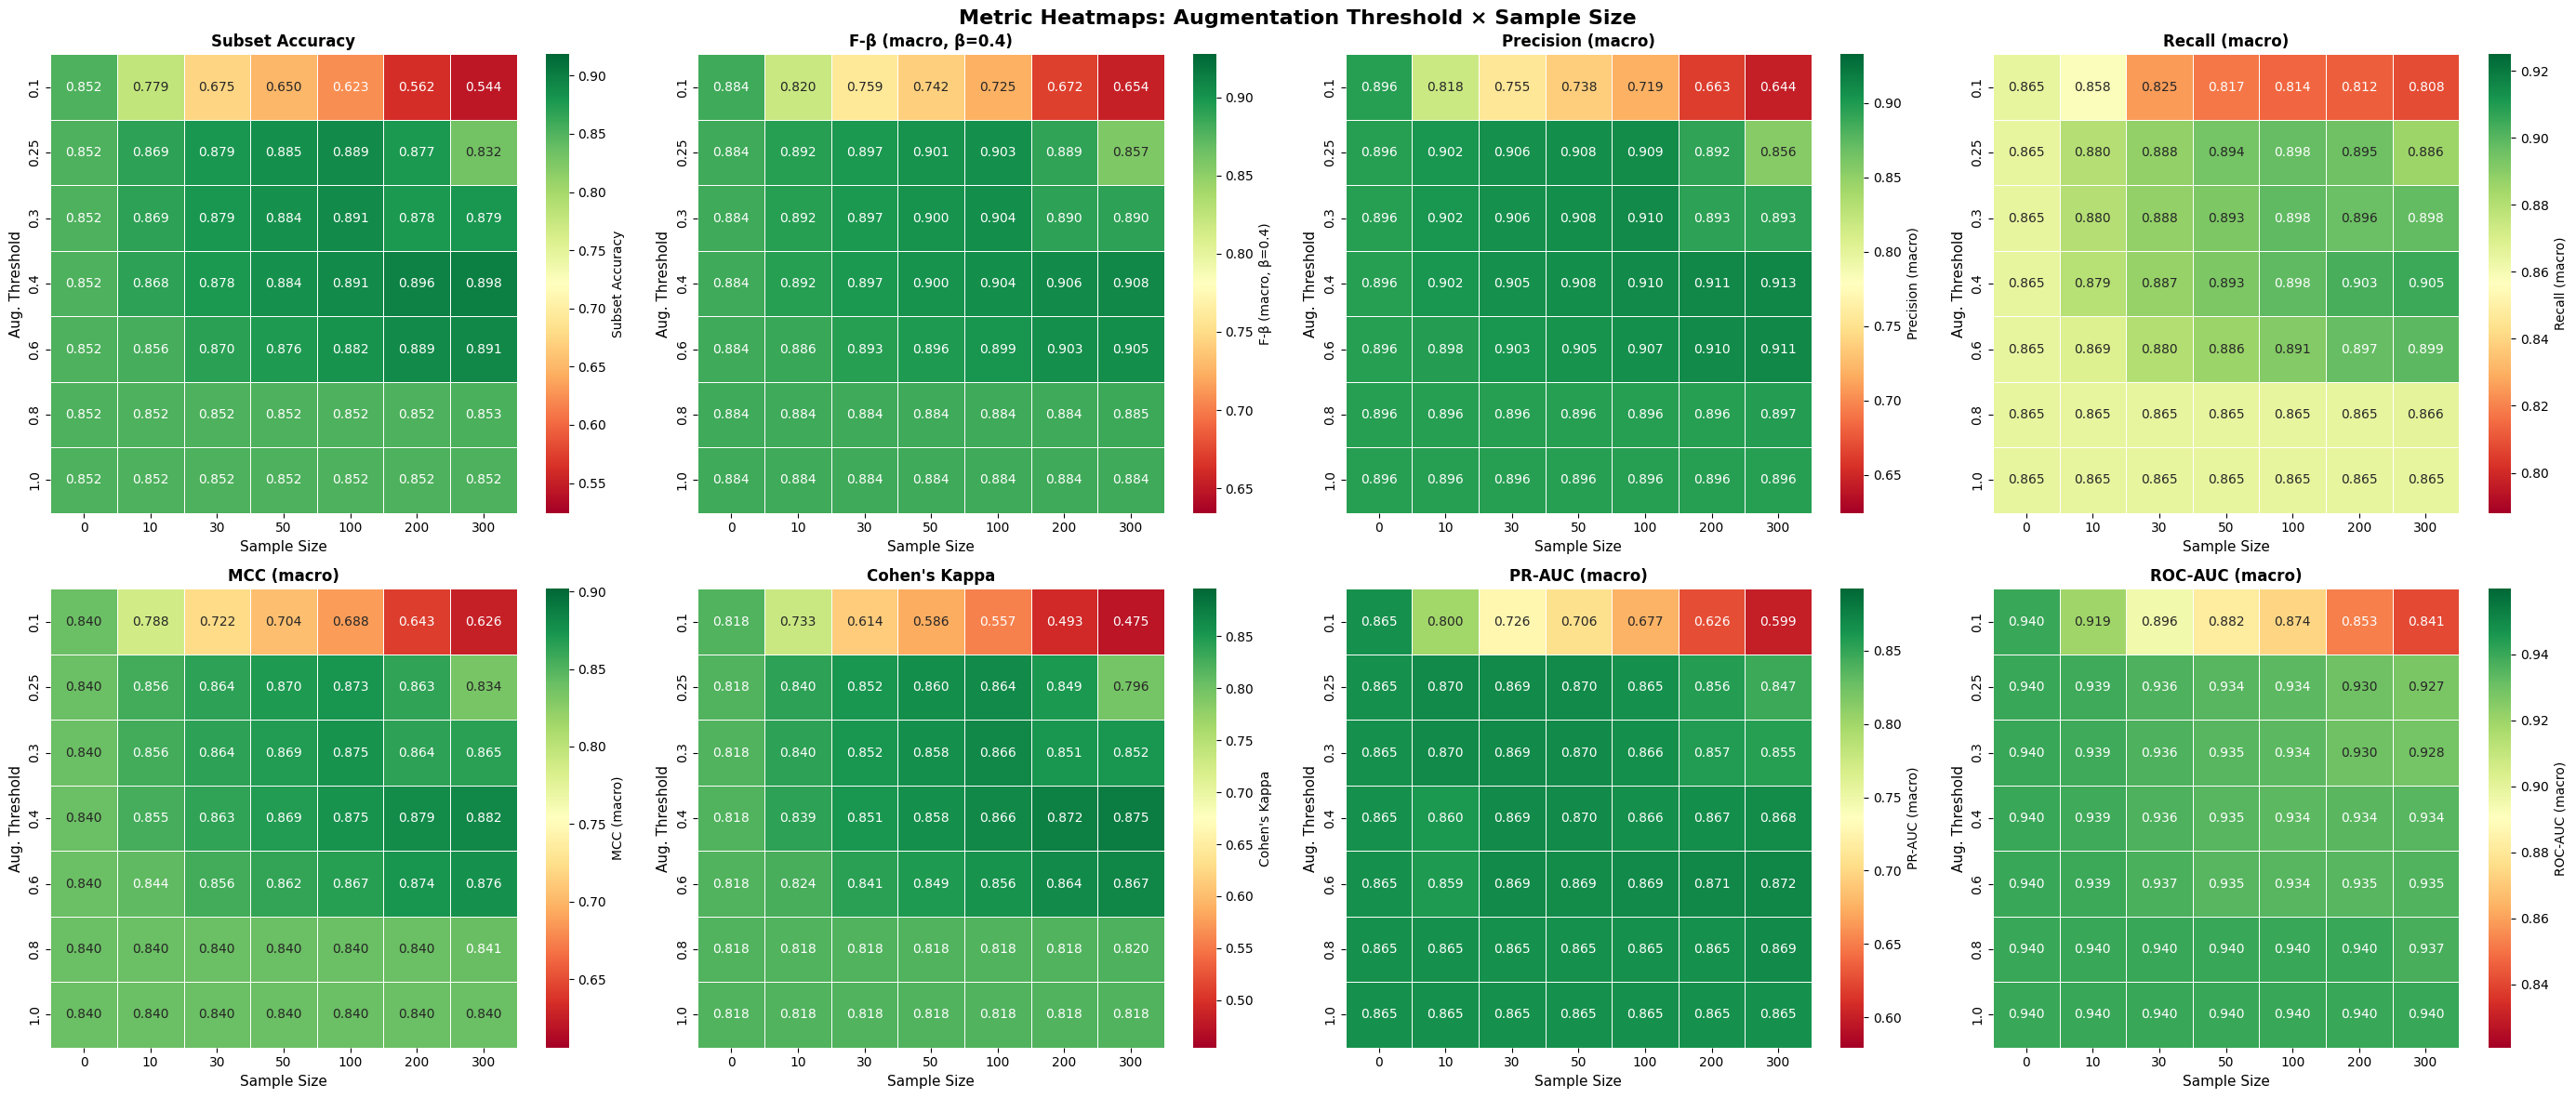

✓ Line plots saved: /app/image_outputs/blind_augmentation_exp_20260221_235304/metrics_vs_samplesize_by_threshold.png


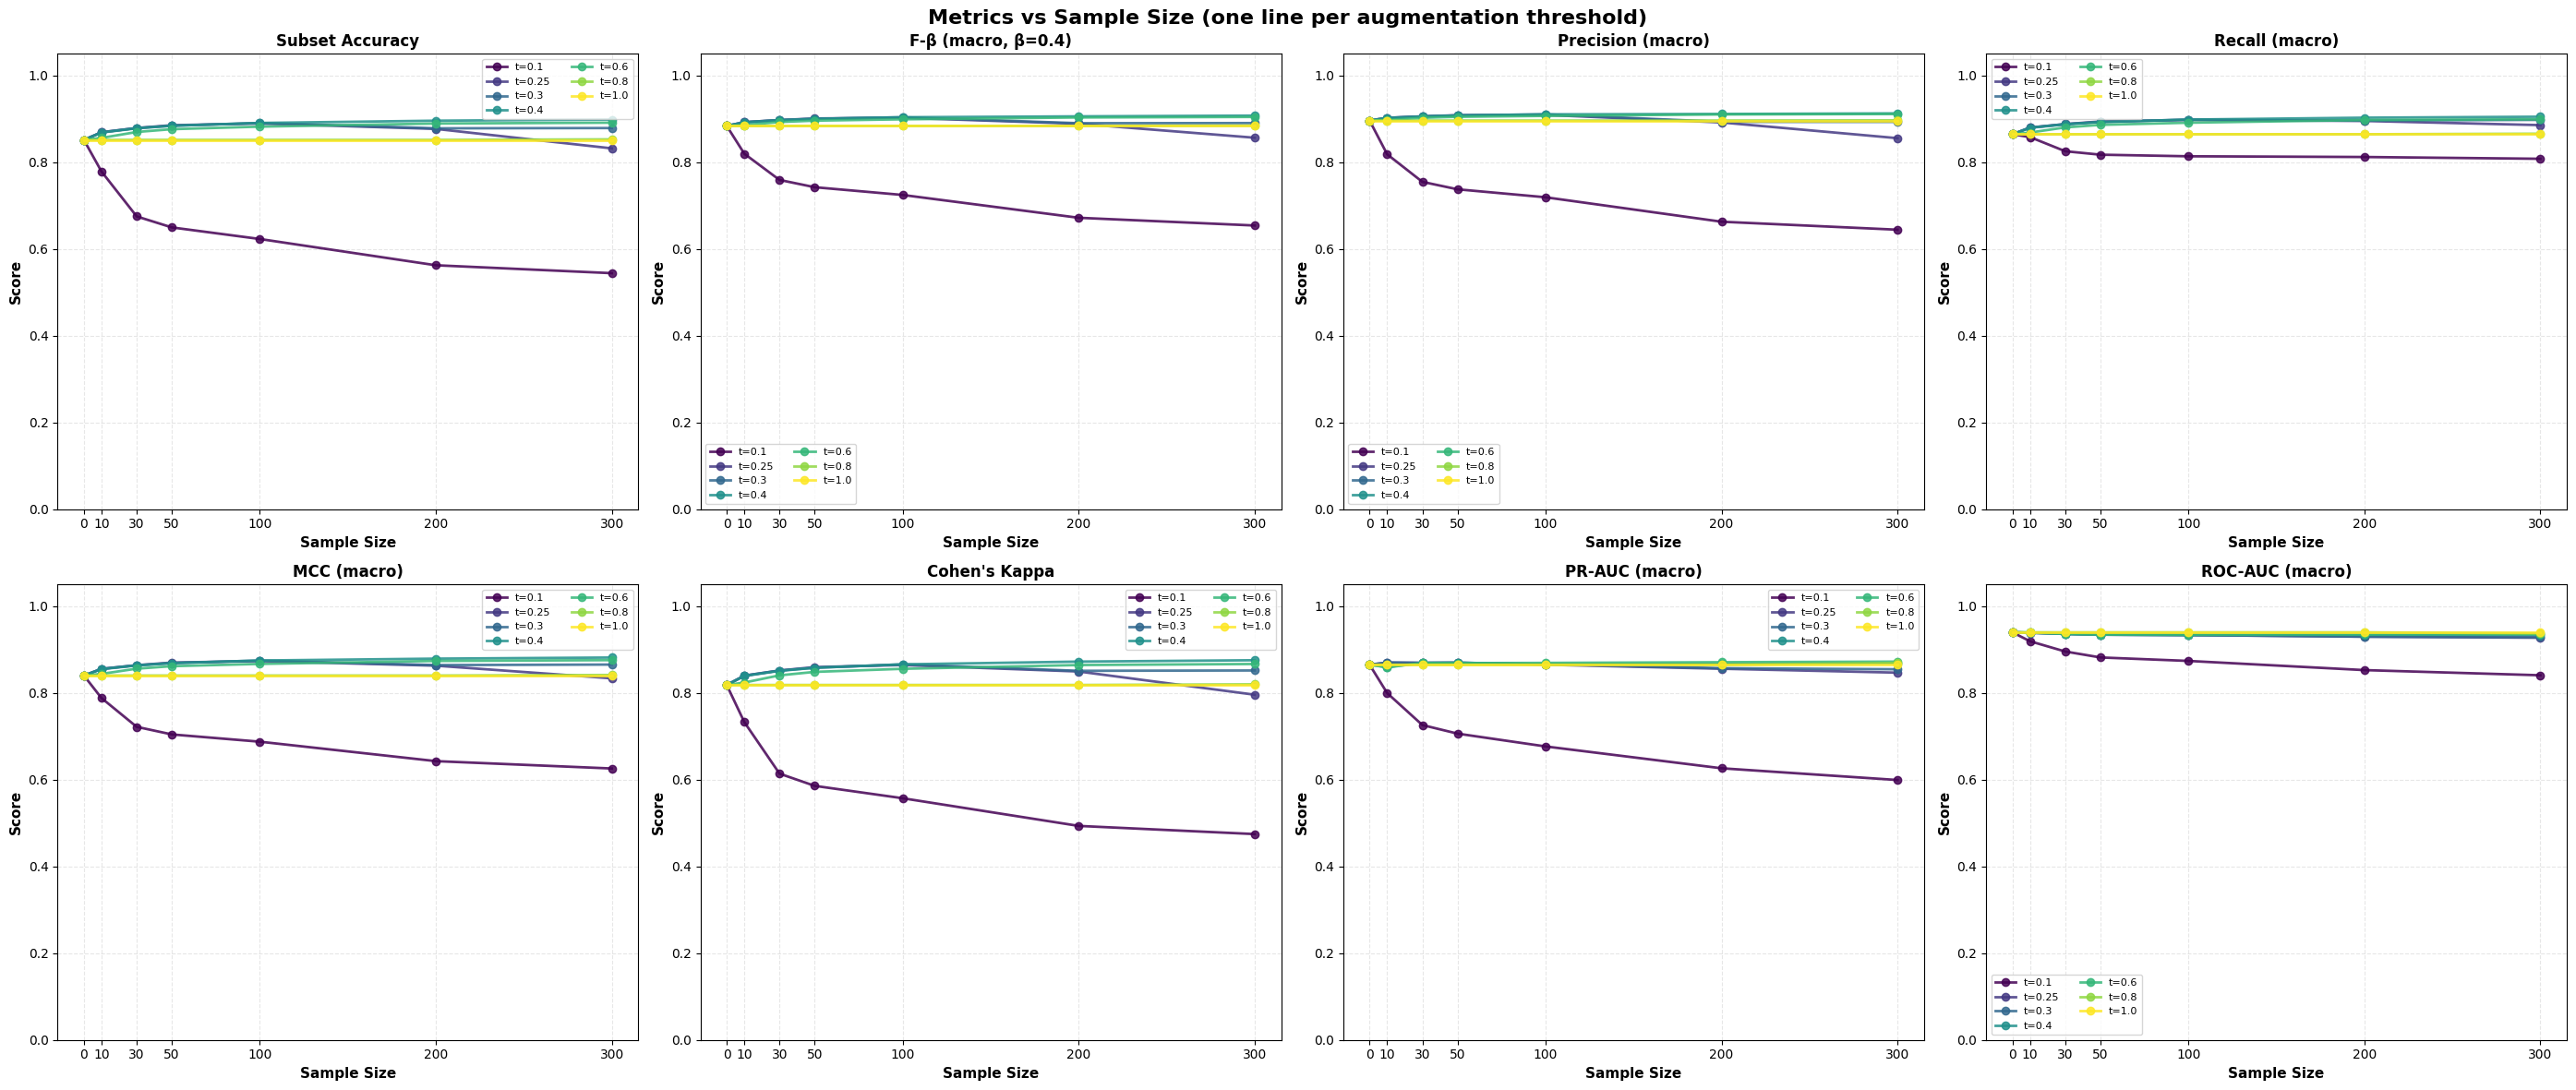

✓ Line plots (by sample size) saved: /app/image_outputs/blind_augmentation_exp_20260221_235304/metrics_vs_threshold_by_samplesize.png


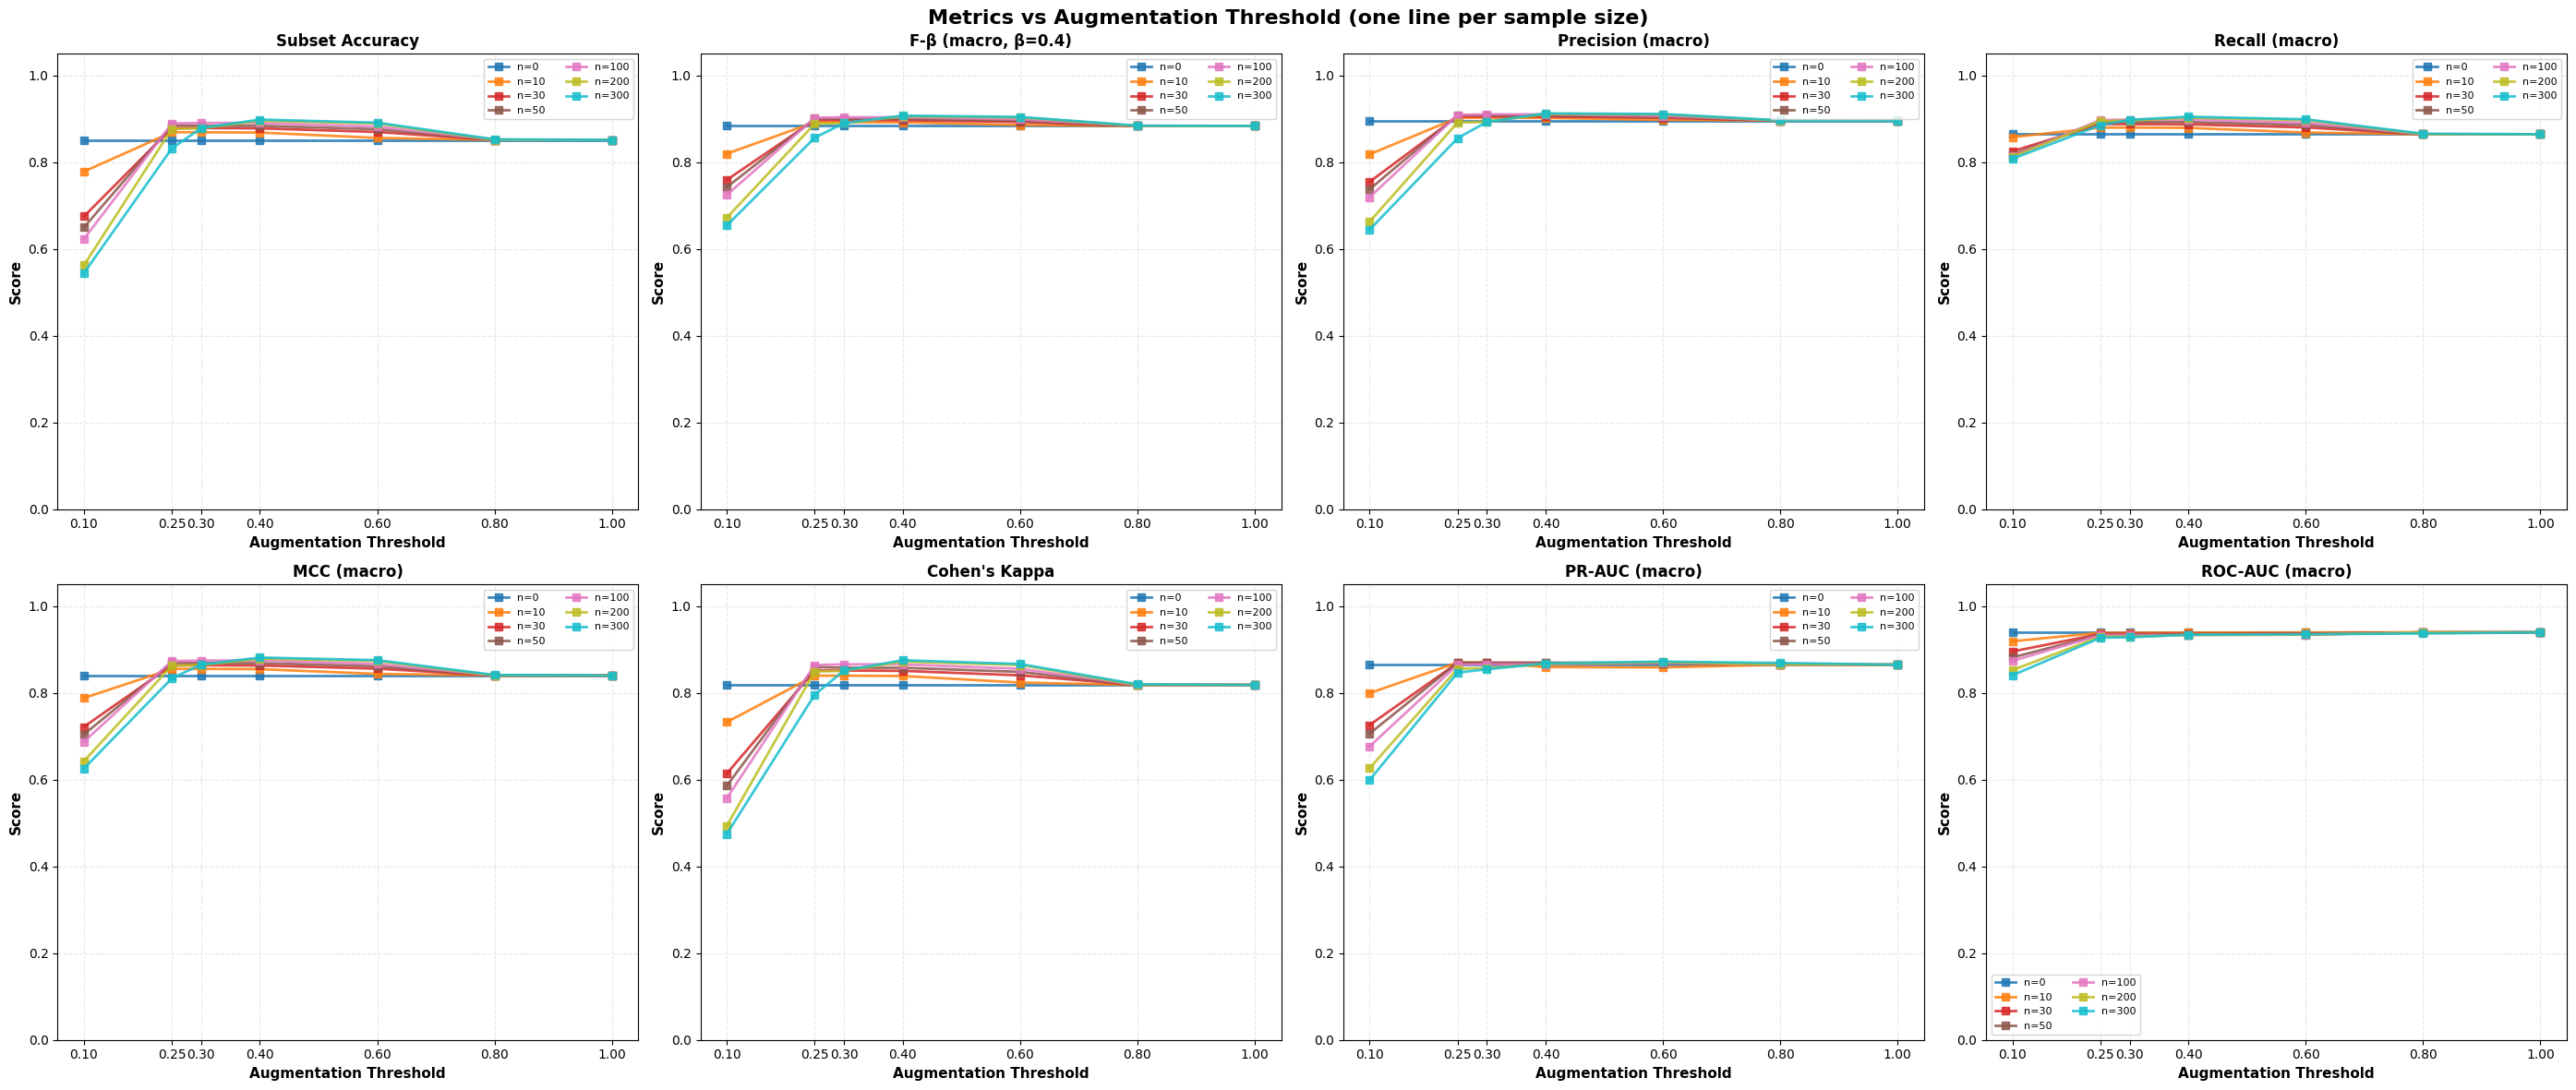

In [10]:
## Heatmaps: Metrics across Threshold × Sample Size grid

metrics_for_heatmaps = [
    ('subset_accuracy', 'Subset Accuracy'),
    ('f_beta_macro', f'F-β (macro, β={F1_BETA})'),
    ('precision_macro', 'Precision (macro)'),
    ('recall_macro', 'Recall (macro)'),
    ('mcc_macro', 'MCC (macro)'),
    ('kappa', "Cohen's Kappa"),
    ('macro_pr_auc', 'PR-AUC (macro)'),
    ('macro_roc_auc', 'ROC-AUC (macro)'),
]

fig, axes = plt.subplots(2, 4, figsize=(28, 12))
fig.suptitle(f"Metric Heatmaps: Augmentation Threshold × Sample Size", fontsize=16, fontweight='bold')

for ax, (metric_key, metric_label) in zip(axes.flat, metrics_for_heatmaps):
    pivot = results_df.pivot_table(index='aug_threshold', columns='sample_size', values=metric_key, aggfunc='first')
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                vmin=pivot.values.min() - 0.02, vmax=min(pivot.values.max() + 0.02, 1.0),
                linewidths=0.5, cbar_kws={'label': metric_label})
    ax.set_title(metric_label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Size', fontsize=11)
    ax.set_ylabel('Aug. Threshold', fontsize=11)

plt.tight_layout()
heatmap_path = EXPERIMENT_DIR / "metric_heatmaps_threshold_x_samplesize.png"
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
print(f"✓ Metric heatmaps saved: {heatmap_path}")
plt.show()

# ═══════════════════════════════════════════════════════════════
# Line plots: One line per threshold, x-axis = sample size
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(28, 12))
fig.suptitle(f"Metrics vs Sample Size (one line per augmentation threshold)", fontsize=16, fontweight='bold')

cmap = plt.cm.viridis
threshold_colors = {t: cmap(i / (len(AUGMENTATION_THRESHOLDS) - 1)) for i, t in enumerate(AUGMENTATION_THRESHOLDS)}

for ax, (metric_key, metric_label) in zip(axes.flat, metrics_for_heatmaps):
    for thresh in AUGMENTATION_THRESHOLDS:
        subset = results_df[results_df['aug_threshold'] == thresh].sort_values('sample_size')
        ax.plot(subset['sample_size'], subset[metric_key], 
                marker='o', linewidth=2, markersize=6,
                color=threshold_colors[thresh], label=f't={thresh}', alpha=0.85)
    
    ax.set_xlabel('Sample Size', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(metric_label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='best', ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.05])
    ax.set_xticks(SAMPLE_SIZES)

plt.tight_layout()
lineplot_path = EXPERIMENT_DIR / "metrics_vs_samplesize_by_threshold.png"
plt.savefig(lineplot_path, dpi=150, bbox_inches='tight')
print(f"✓ Line plots saved: {lineplot_path}")
plt.show()

# ═══════════════════════════════════════════════════════════════
# Line plots: One line per sample size, x-axis = threshold
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(28, 12))
fig.suptitle(f"Metrics vs Augmentation Threshold (one line per sample size)", fontsize=16, fontweight='bold')

sample_colors = plt.cm.tab10(np.linspace(0, 1, len(SAMPLE_SIZES)))

for ax, (metric_key, metric_label) in zip(axes.flat, metrics_for_heatmaps):
    for i, ss in enumerate(SAMPLE_SIZES):
        subset = results_df[results_df['sample_size'] == ss].sort_values('aug_threshold')
        ax.plot(subset['aug_threshold'], subset[metric_key],
                marker='s', linewidth=2, markersize=6,
                color=sample_colors[i], label=f'n={ss}', alpha=0.85)
    
    ax.set_xlabel('Augmentation Threshold', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(metric_label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='best', ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.05])
    ax.set_xticks(AUGMENTATION_THRESHOLDS)

plt.tight_layout()
lineplot2_path = EXPERIMENT_DIR / "metrics_vs_threshold_by_samplesize.png"
plt.savefig(lineplot2_path, dpi=150, bbox_inches='tight')
print(f"✓ Line plots (by sample size) saved: {lineplot2_path}")
plt.show()

# Detailed Analysis

## Macro-Averaged PR & ROC Curves

For each augmentation threshold, show how sample size affects the PR and ROC curves (macro-averaged across classes).

MACRO-AVERAGED PR & ROC CURVES — SELECTED CONFIGURATIONS
✓ PR and ROC curve comparisons saved


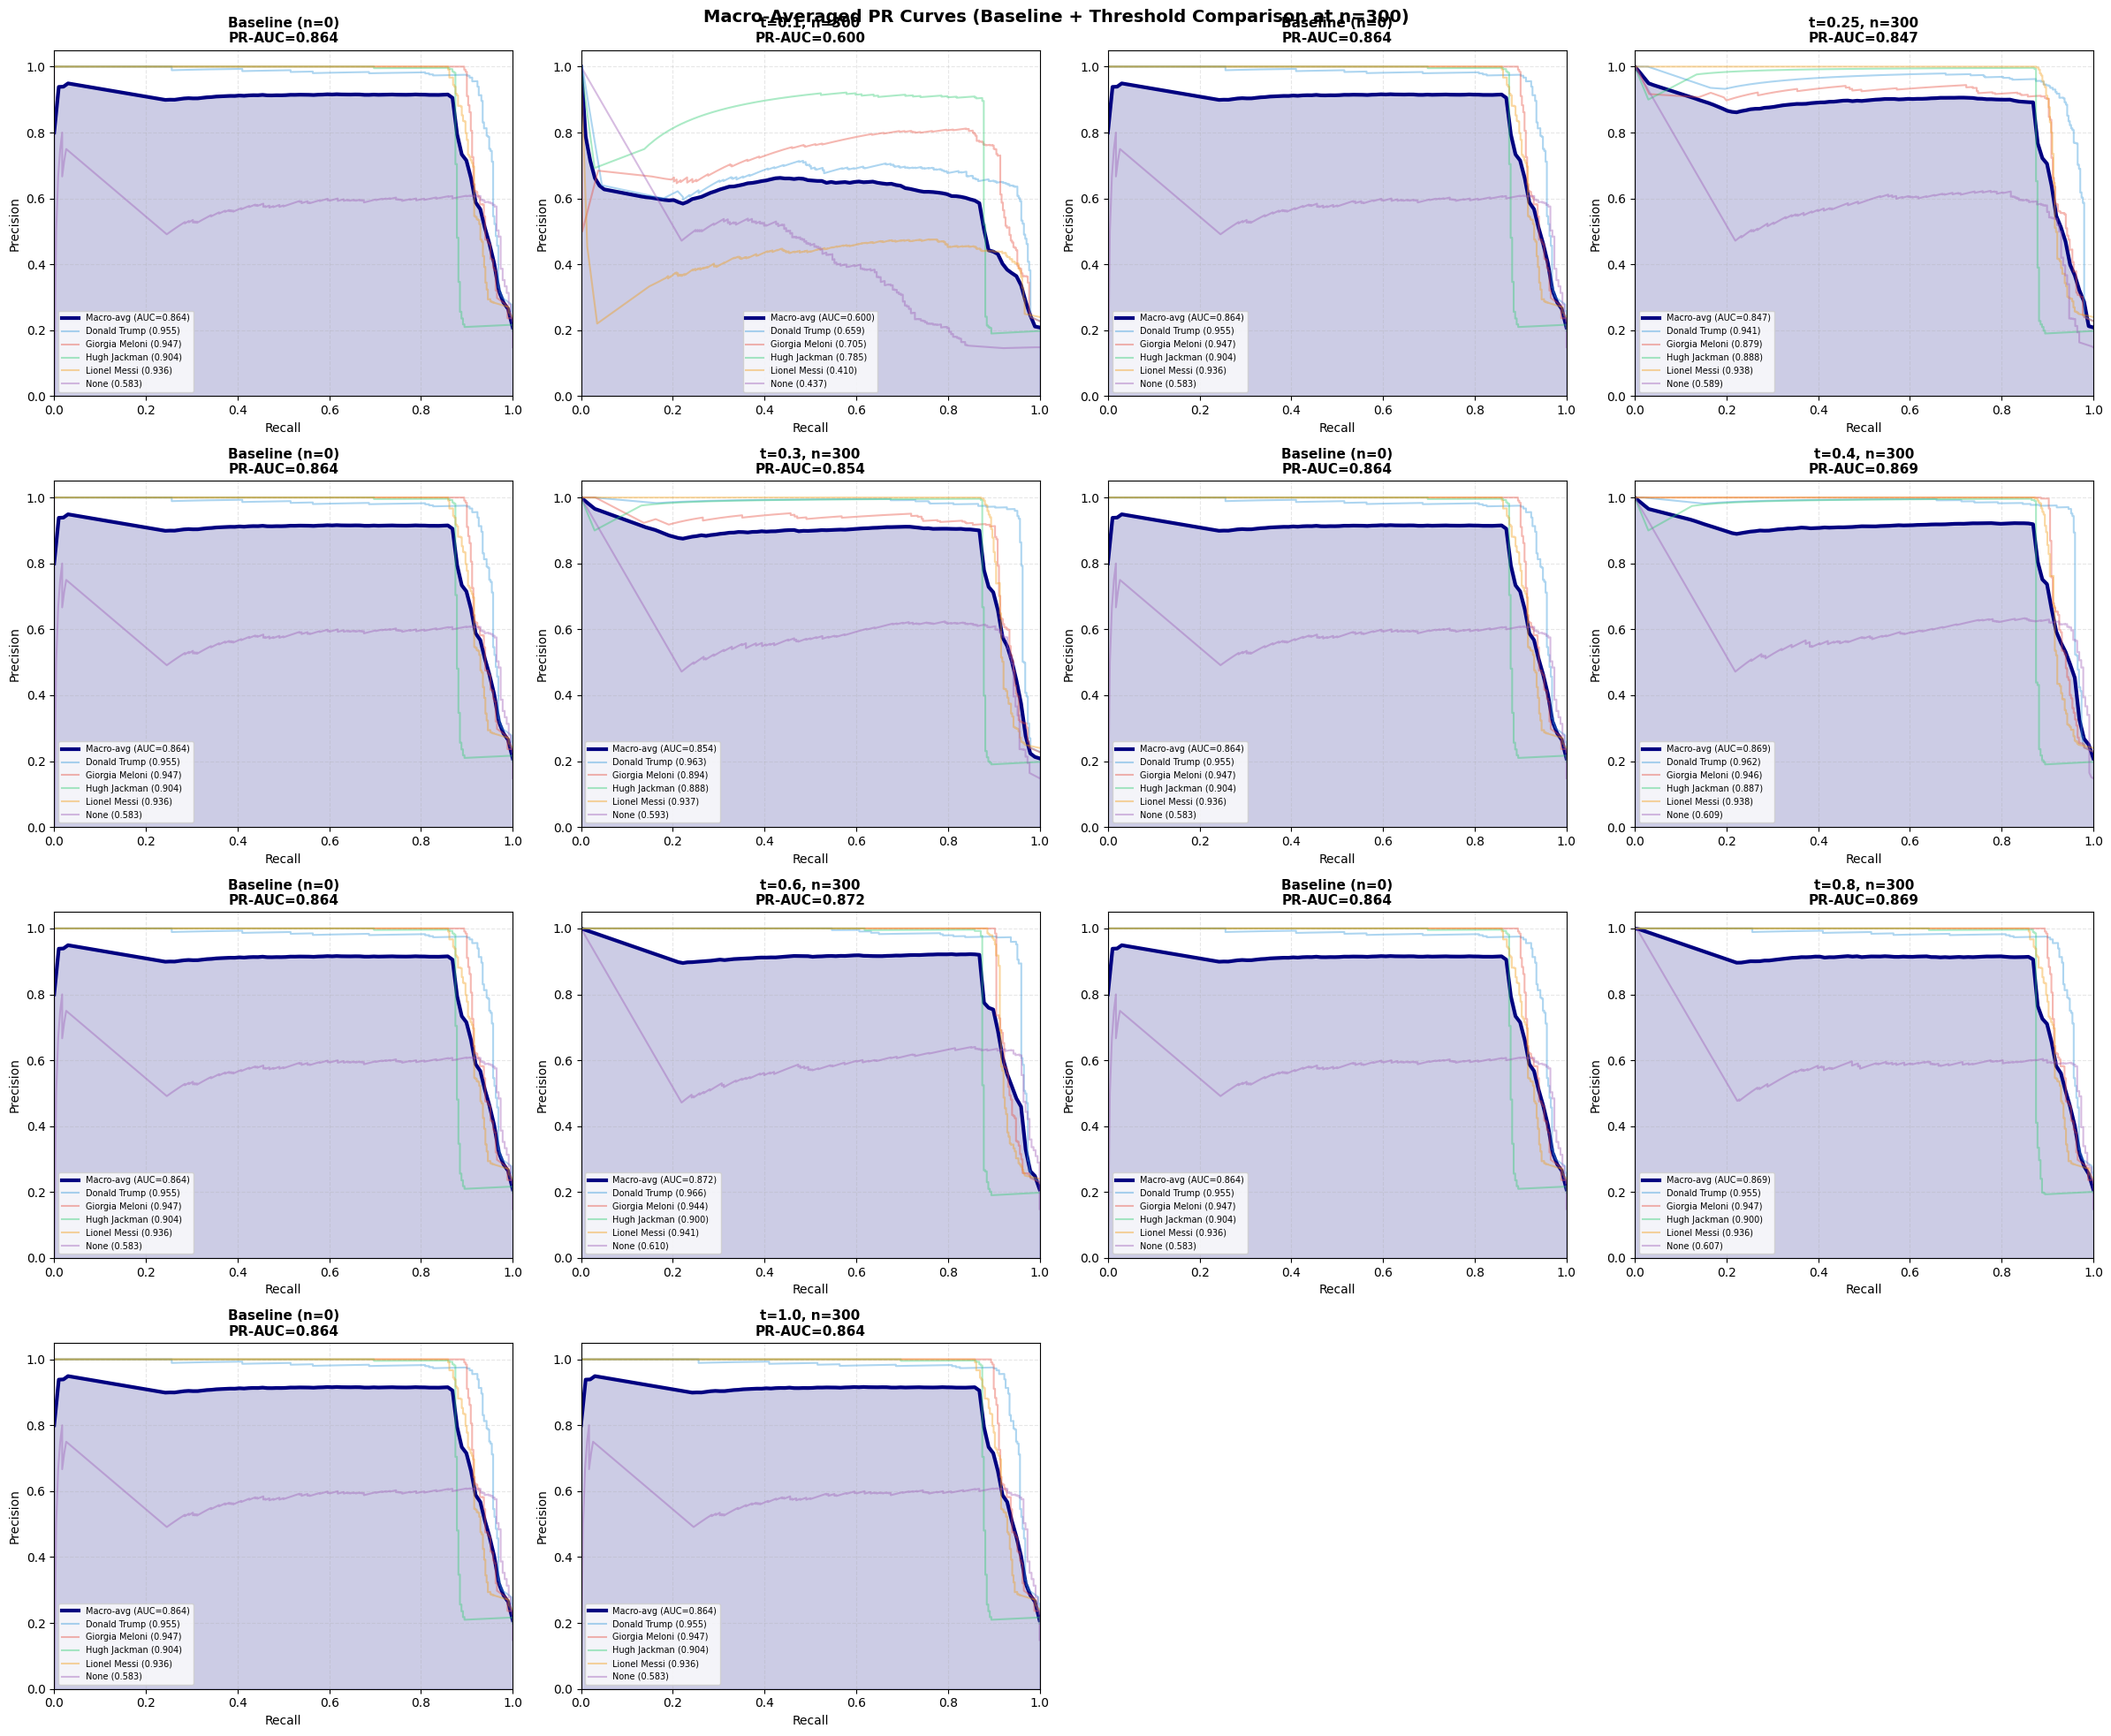

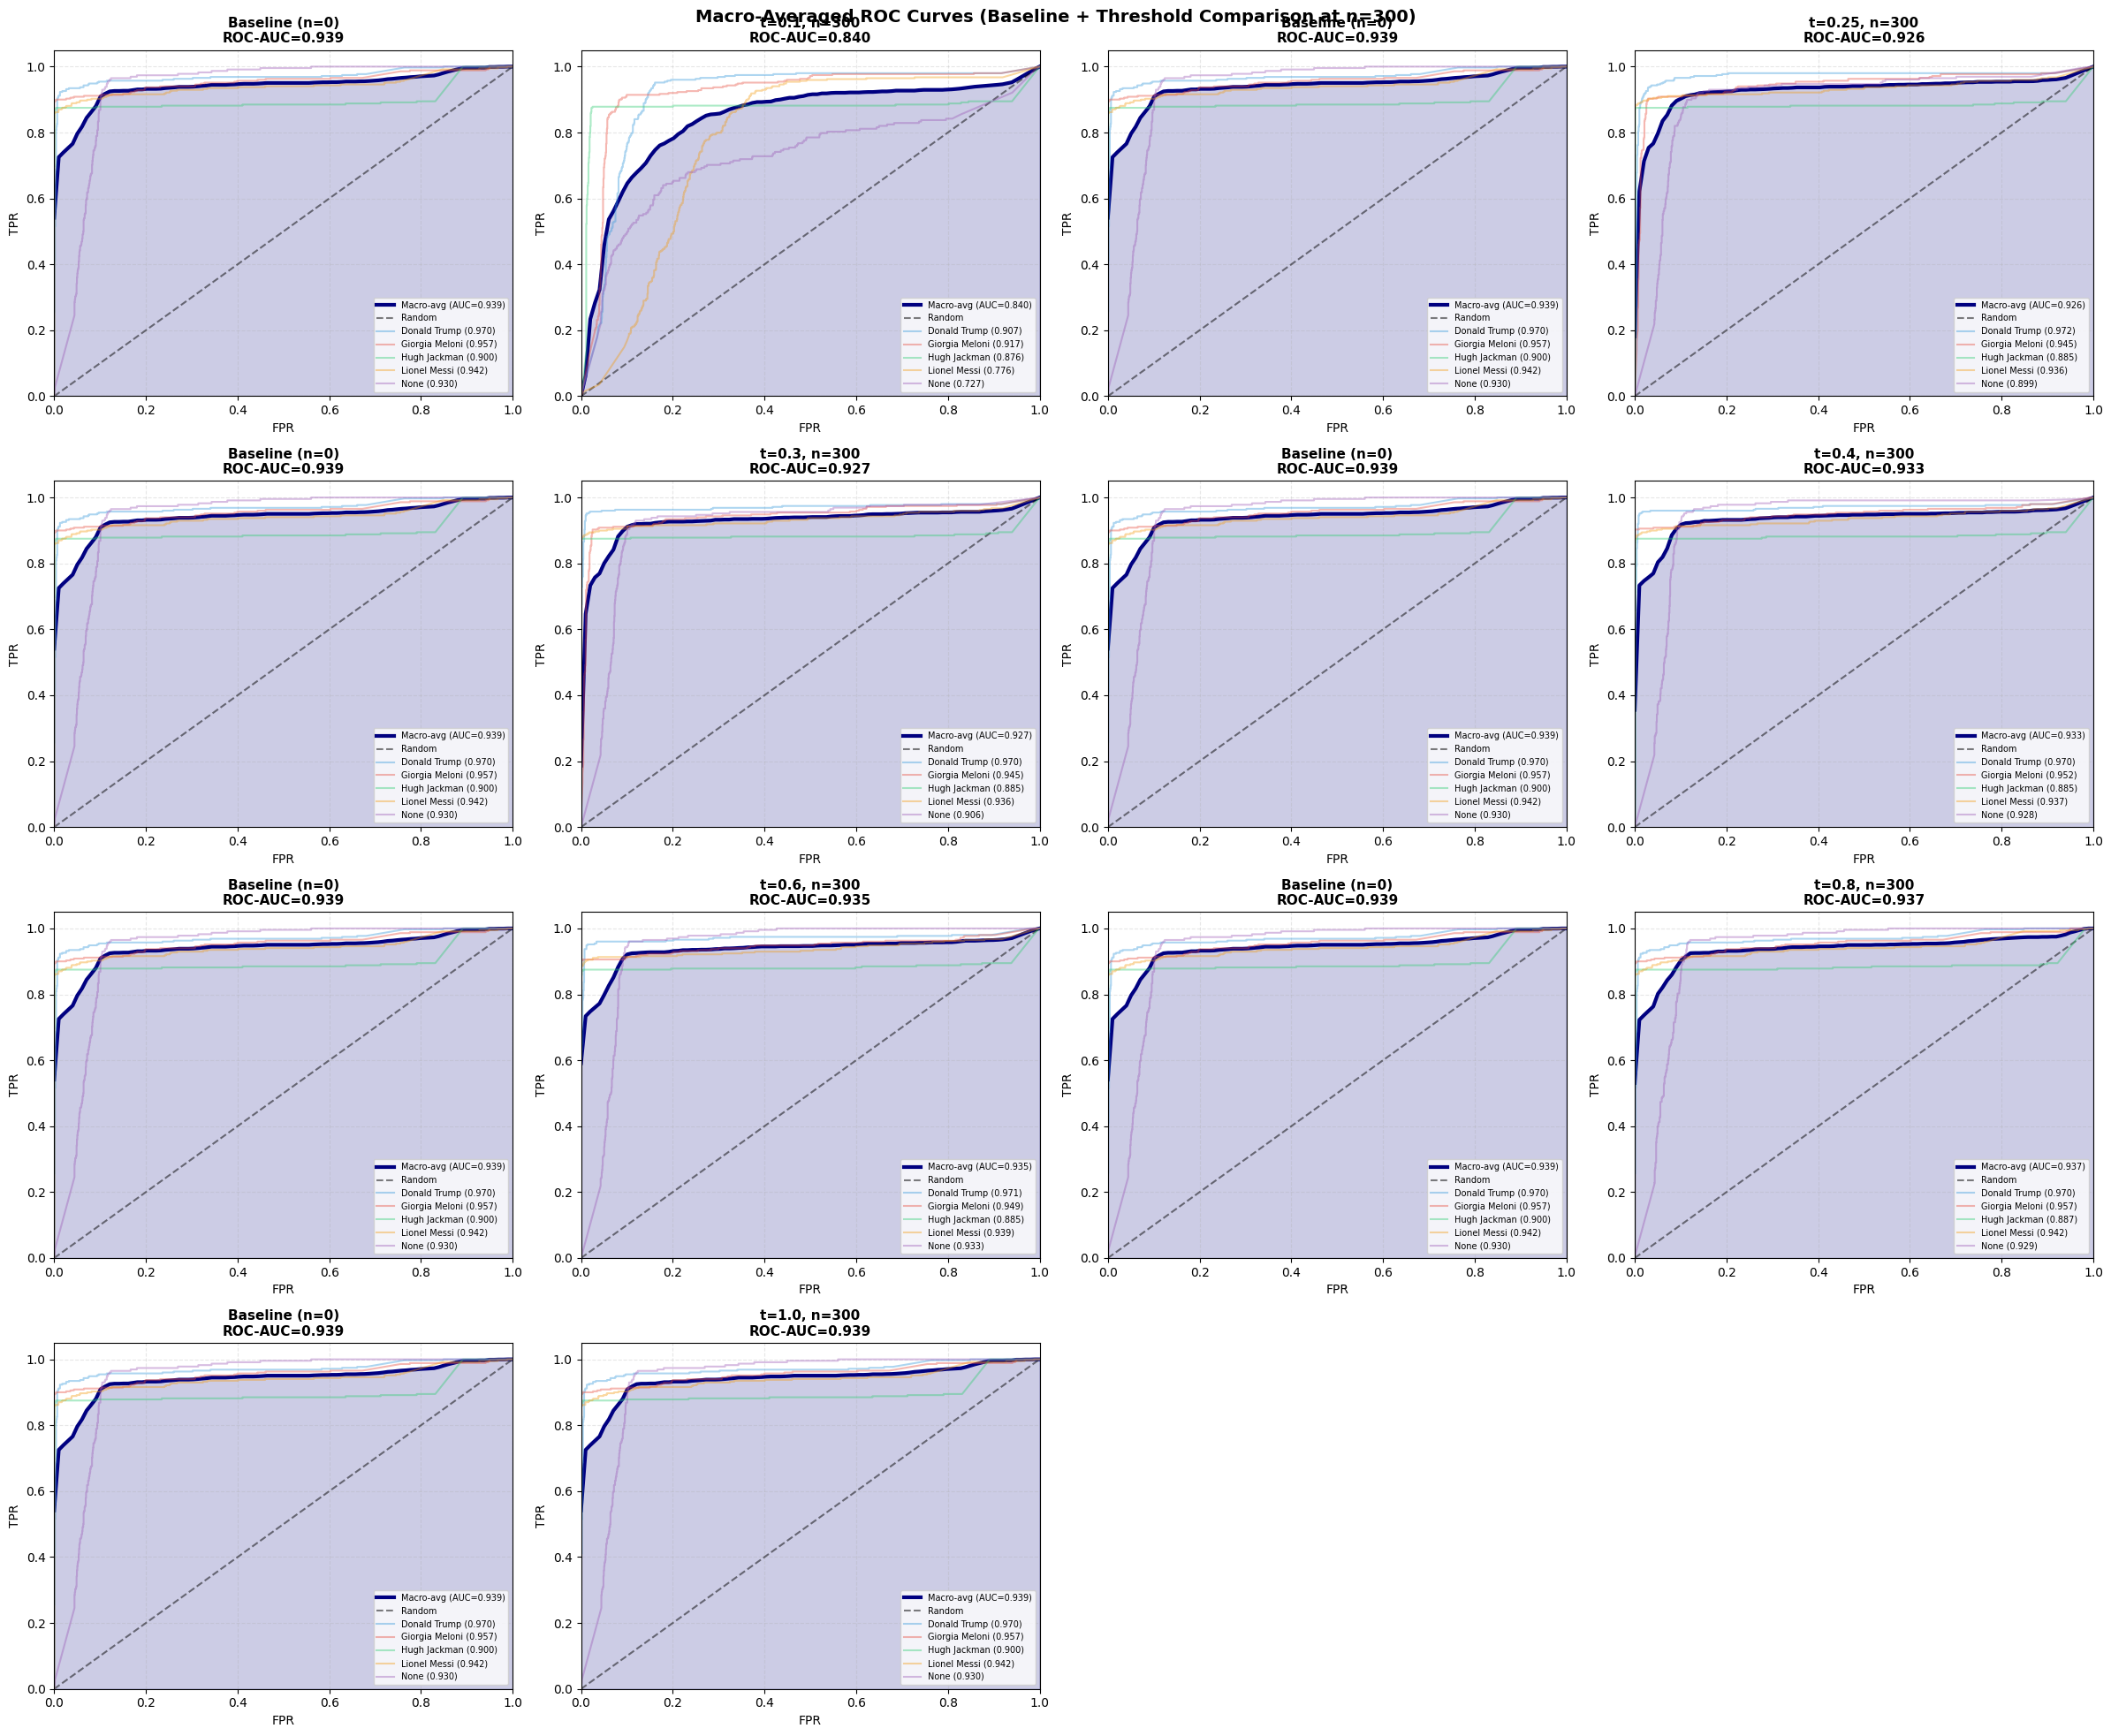

In [11]:
print("=" * 100)
print("MACRO-AVERAGED PR & ROC CURVES — SELECTED CONFIGURATIONS")
print("=" * 100)

# Show curves for: baseline (sample_size=0) + best threshold at each sample size
# Group by threshold, pick a representative sample_size per threshold
selected_sample_size = max(SAMPLE_SIZES)  # Use largest sample size for comparison

# Filter: baseline + each threshold at max sample size
selected_configs = [d for d in iteration_detailed_data 
                    if d['sample_size'] == 0 or d['sample_size'] == selected_sample_size]

ncols = min(4, len(selected_configs))
nrows = math.ceil(len(selected_configs) / ncols)

# PR curves
fig_pr, axes_pr = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
fig_pr.suptitle(f"Macro-Averaged PR Curves (Baseline + Threshold Comparison at n={selected_sample_size})", fontsize=14, fontweight='bold')
axes_pr_flat = np.array(axes_pr).flatten() if len(selected_configs) > 1 else [axes_pr]

# ROC curves
fig_roc, axes_roc = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
fig_roc.suptitle(f"Macro-Averaged ROC Curves (Baseline + Threshold Comparison at n={selected_sample_size})", fontsize=14, fontweight='bold')
axes_roc_flat = np.array(axes_roc).flatten() if len(selected_configs) > 1 else [axes_roc]

colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for iter_idx, iter_data in enumerate(selected_configs):
    if iter_idx >= len(axes_pr_flat):
        break
    
    sample_size = iter_data['sample_size']
    aug_threshold = iter_data['aug_threshold']
    y_true = iter_data['y_true']
    scores = iter_data['scores']
    class_names = iter_data['class_names']
    
    if y_true is None or not class_names:
        continue
    
    all_precisions = []
    all_recalls = []
    all_fprs = []
    all_tprs = []
    
    for class_idx, class_name in enumerate(class_names):
        y_true_binary = y_true[:, class_idx]
        if class_name == 'None':
            y_scores = np.array([1 - max(s.values()) if s else 1.0 for s in scores])
        else:
            y_scores = np.array([s.get(class_name, 0.0) for s in scores])
        
        prec_c, rec_c, _ = precision_recall_curve(y_true_binary, y_scores)
        all_precisions.append(prec_c)
        all_recalls.append(rec_c)
        
        try:
            fpr_c, tpr_c, _ = roc_curve(y_true_binary, y_scores)
            all_fprs.append(fpr_c)
            all_tprs.append(tpr_c)
        except ValueError:
            pass
    
    # Macro PR
    mean_recall = np.linspace(0, 1, 100)
    mean_precision = np.zeros_like(mean_recall)
    for prec_c, rec_c in zip(all_precisions, all_recalls):
        mean_precision += np.interp(mean_recall, rec_c[::-1], prec_c[::-1])
    mean_precision /= len(all_precisions)
    macro_pr_auc = float(sk_auc(mean_recall, mean_precision))
    
    ax_pr = axes_pr_flat[iter_idx]
    ax_pr.plot(mean_recall, mean_precision, linewidth=3, color='navy', label=f'Macro-avg (AUC={macro_pr_auc:.3f})')
    ax_pr.fill_between(mean_recall, mean_precision, alpha=0.2, color='navy')
    for idx, (prec_c, rec_c, cn) in enumerate(zip(all_precisions, all_recalls, class_names)):
        try:
            auc_val = float(sk_auc(rec_c, prec_c))
        except ValueError:
            auc_val = 0.0
        ax_pr.plot(rec_c, prec_c, linewidth=1.5, alpha=0.4,
               color=colors_palette[idx % len(colors_palette)], label=f'{cn} ({auc_val:.3f})')
    
    title_str = f'Baseline (n=0)' if sample_size == 0 else f't={aug_threshold}, n={sample_size}'
    ax_pr.set_title(f'{title_str}\nPR-AUC={macro_pr_auc:.3f}', fontsize=11, fontweight='bold')
    ax_pr.set_xlabel('Recall', fontsize=10)
    ax_pr.set_ylabel('Precision', fontsize=10)
    ax_pr.set_xlim([0, 1]); ax_pr.set_ylim([0, 1.05])
    ax_pr.legend(fontsize=7, loc='best')
    ax_pr.grid(True, alpha=0.3, linestyle='--')
    
    # Macro ROC
    if all_fprs:
        mean_fpr = np.linspace(0, 1, 100)
        mean_tpr = np.zeros_like(mean_fpr)
        for fpr_c, tpr_c in zip(all_fprs, all_tprs):
            mean_tpr += np.interp(mean_fpr, fpr_c, tpr_c)
        mean_tpr /= len(all_fprs)
        macro_roc_auc = float(sk_auc(mean_fpr, mean_tpr))
        
        ax_roc = axes_roc_flat[iter_idx]
        ax_roc.plot(mean_fpr, mean_tpr, linewidth=3, color='navy', label=f'Macro-avg (AUC={macro_roc_auc:.3f})')
        ax_roc.fill_between(mean_fpr, mean_tpr, alpha=0.2, color='navy')
        ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random')
        for idx, (fpr_c, tpr_c, cn) in enumerate(zip(all_fprs, all_tprs, class_names)):
            try:
                auc_val = float(sk_auc(fpr_c, tpr_c))
            except ValueError:
                auc_val = 0.0
            ax_roc.plot(fpr_c, tpr_c, linewidth=1.5, alpha=0.4,
                   color=colors_palette[idx % len(colors_palette)], label=f'{cn} ({auc_val:.3f})')
        
        ax_roc.set_title(f'{title_str}\nROC-AUC={macro_roc_auc:.3f}', fontsize=11, fontweight='bold')
        ax_roc.set_xlabel('FPR', fontsize=10)
        ax_roc.set_ylabel('TPR', fontsize=10)
        ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.05])
        ax_roc.legend(fontsize=7, loc='best')
        ax_roc.grid(True, alpha=0.3, linestyle='--')

# Hide unused
for idx in range(len(selected_configs), len(axes_pr_flat)):
    axes_pr_flat[idx].axis('off')
for idx in range(len(selected_configs), len(axes_roc_flat)):
    axes_roc_flat[idx].axis('off')

plt.figure(fig_pr.number)
plt.tight_layout()
fig_pr.savefig(EXPERIMENT_DIR / "macro_pr_curves_comparison.png", dpi=150, bbox_inches='tight')

plt.figure(fig_roc.number)
plt.tight_layout()
fig_roc.savefig(EXPERIMENT_DIR / "macro_roc_curves_comparison.png", dpi=150, bbox_inches='tight')

print(f"✓ PR and ROC curve comparisons saved")
plt.show()

In [12]:
## Per-Class Evaluation — Metrics Tables (Best Config + Baseline)

print("=" * 120)
print("PER-CLASS EVALUATION METRICS — BASELINE vs BEST CONFIG")
print("=" * 120)

# Show baseline and the overall best F-beta config
best_fbeta_idx = results_df['f_beta_macro'].idxmax()
configs_to_show = [
    ("Baseline (no augmentation)", 
     next(d for d in iteration_detailed_data if d['sample_size'] == 0)),
    (f"Best F-β (t={results_df.loc[best_fbeta_idx, 'aug_threshold']}, n={int(results_df.loc[best_fbeta_idx, 'sample_size'])})", 
     iteration_detailed_data[best_fbeta_idx]),
]

for config_name, iter_data in configs_to_show:
    per_class_metrics = iter_data['per_class_metrics']
    if not per_class_metrics:
        continue
    
    print(f"\n{'─' * 120}")
    print(f"{config_name}")
    print(f"{'─' * 120}")
    
    metrics_df = pd.DataFrame(per_class_metrics).T
    column_order = ['accuracy', 'precision', 'recall', 'f_beta', 'mcc', 'roc_auc', 'pr_auc',
                    'precision_at_fixed_recall', 'recall_at_fixed_precision', 'support', 'tp', 'fp', 'fn', 'tn']
    available_cols = [col for col in column_order if col in metrics_df.columns]
    metrics_df = metrics_df[available_cols]
    
    col_names = {
        'accuracy': 'Accuracy', 'precision': 'Precision', 'recall': 'Recall',
        'f_beta': f'F-β({F1_BETA})', 'mcc': 'MCC', 'roc_auc': 'ROC-AUC', 'pr_auc': 'PR-AUC',
        'precision_at_fixed_recall': f'P@R={FIXED_RECALL_LEVEL}',
        'recall_at_fixed_precision': f'R@P={FIXED_PRECISION_LEVEL}',
        'support': 'Support', 'tp': 'TP', 'fp': 'FP', 'fn': 'FN', 'tn': 'TN'
    }
    metrics_df = metrics_df.rename(columns={c: col_names[c] for c in available_cols if c in col_names})
    print(metrics_df.to_string())
    
    # Summary
    float_cols = [c for c in metrics_df.columns if metrics_df[c].dtype in [float, np.float64]]
    print(f"\n  Mean Accuracy: {metrics_df['Accuracy'].mean():.4f}")
    print(f"  Mean Precision: {metrics_df['Precision'].mean():.4f}")
    print(f"  Mean Recall: {metrics_df['Recall'].mean():.4f}")
    print(f"  Mean MCC: {metrics_df['MCC'].mean():.4f}")
    
    best_class = metrics_df[f'F-β({F1_BETA})'].idxmax()
    worst_class = metrics_df[f'F-β({F1_BETA})'].idxmin()
    print(f"  Best class:  {best_class} (F-β={metrics_df.loc[best_class, f'F-β({F1_BETA})']:.4f})")
    print(f"  Worst class: {worst_class} (F-β={metrics_df.loc[worst_class, f'F-β({F1_BETA})']:.4f})")

print(f"\n{'=' * 120}")

PER-CLASS EVALUATION METRICS — BASELINE vs BEST CONFIG

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Baseline (no augmentation)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                Accuracy  Precision    Recall  F-β(0.4)       MCC   ROC-AUC    PR-AUC  P@R=0.95  R@P=0.95  Support     TP     FP    FN      TN
Donald Trump    0.956380   0.973333  0.831909  0.951033  0.873936  0.970292  0.955207  0.750253  0.923077    351.0  292.0    8.0  59.0  1177.0
Giorgia Meloni  0.970703   1.000000  0.871429  0.980055  0.916282  0.956968  0.947376  0.460845  0.900000    350.0  305.0    0.0  45.0  1186.0
Hugh Jackman    0.967448   0.996094  0.838816  0.970982  0.895908  0.899724  0.903978  0.213529  0.875000    304.0  255.0    1.0  49.0  1231.0
Lionel Messi    0.955729   1.000000  0.815718  0.969781  0.877955  0.942114  0.936429  0.294197  0.8699

✓ Per-class heatmaps saved: /app/image_outputs/blind_augmentation_exp_20260221_235304/per_class_heatmap_n300.png


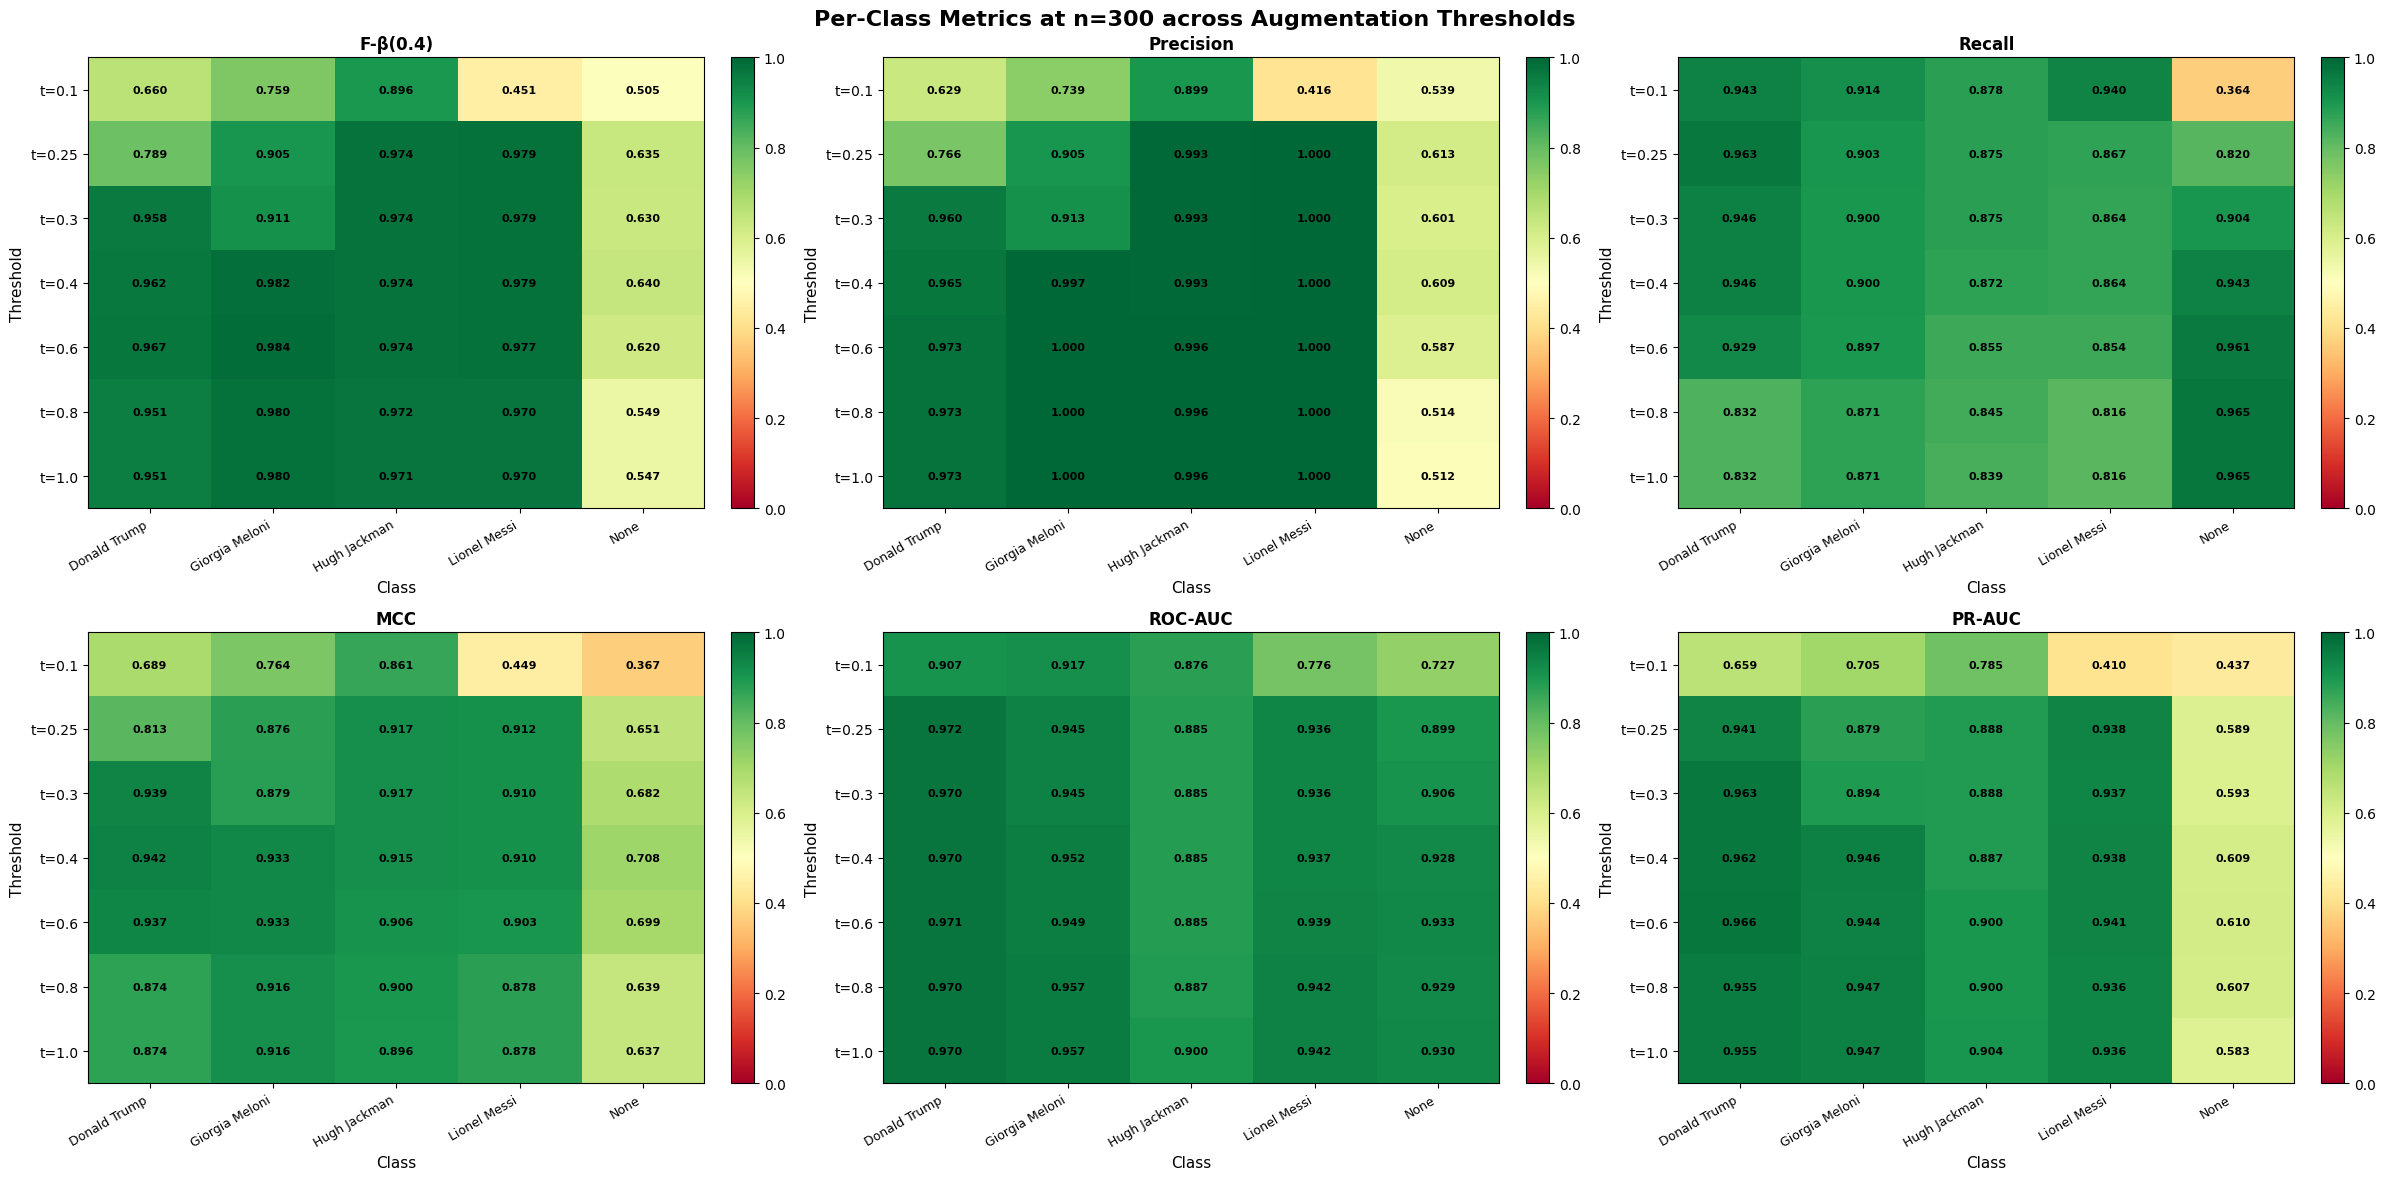

In [13]:
## Per-Class Metrics Heatmaps — Best threshold per sample size

# For each sample size, find the best threshold by F-beta, then show per-class breakdown
all_classes = set()
for iter_data in iteration_detailed_data:
    if iter_data['per_class_metrics']:
        all_classes.update(iter_data['per_class_metrics'].keys())
all_classes = sorted(list(all_classes))

if not all_classes:
    print("⚠️  No per-class data available")
else:
    # Show per-class F-beta heatmap: class × threshold (at max sample size)
    max_ss = max(SAMPLE_SIZES)
    metrics_to_heatmap = ['f_beta', 'precision', 'recall', 'mcc', 'roc_auc', 'pr_auc']
    metric_labels = [f'F-β({F1_BETA})', 'Precision', 'Recall', 'MCC', 'ROC-AUC', 'PR-AUC']
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 12))
    fig.suptitle(f"Per-Class Metrics at n={max_ss} across Augmentation Thresholds", fontsize=16, fontweight='bold')
    
    for ax, metric_name, metric_label in zip(axes.flat, metrics_to_heatmap, metric_labels):
        matrix = []
        threshold_labels = []
        
        for thresh in AUGMENTATION_THRESHOLDS:
            matching = [d for d in iteration_detailed_data 
                       if d['aug_threshold'] == thresh and d['sample_size'] == max_ss]
            if not matching:
                continue
            iter_data = matching[0]
            row = []
            for class_name in all_classes:
                if class_name in iter_data['per_class_metrics']:
                    row.append(iter_data['per_class_metrics'][class_name].get(metric_name, 0.0))
                else:
                    row.append(0.0)
            matrix.append(row)
            threshold_labels.append(thresh)
        
        if not matrix:
            ax.axis('off')
            continue
        
        matrix = np.array(matrix)
        im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        ax.set_xticks(np.arange(len(all_classes)))
        ax.set_yticks(np.arange(len(threshold_labels)))
        ax.set_xticklabels(all_classes, fontsize=9, rotation=30, ha='right')
        ax.set_yticklabels([f't={t}' for t in threshold_labels], fontsize=10)
        ax.set_xlabel('Class', fontsize=11)
        ax.set_ylabel('Threshold', fontsize=11)
        ax.set_title(metric_label, fontsize=12, fontweight='bold')
        
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, f'{matrix[i, j]:.3f}', ha='center', va='center', fontsize=8, fontweight='bold')
        
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    per_class_heatmap_path = EXPERIMENT_DIR / f"per_class_heatmap_n{max_ss}.png"
    plt.savefig(per_class_heatmap_path, dpi=150, bbox_inches='tight')
    print(f"✓ Per-class heatmaps saved: {per_class_heatmap_path}")
    plt.show()

PER-CLASS PRECISION-RECALL CURVES — BASELINE vs BEST


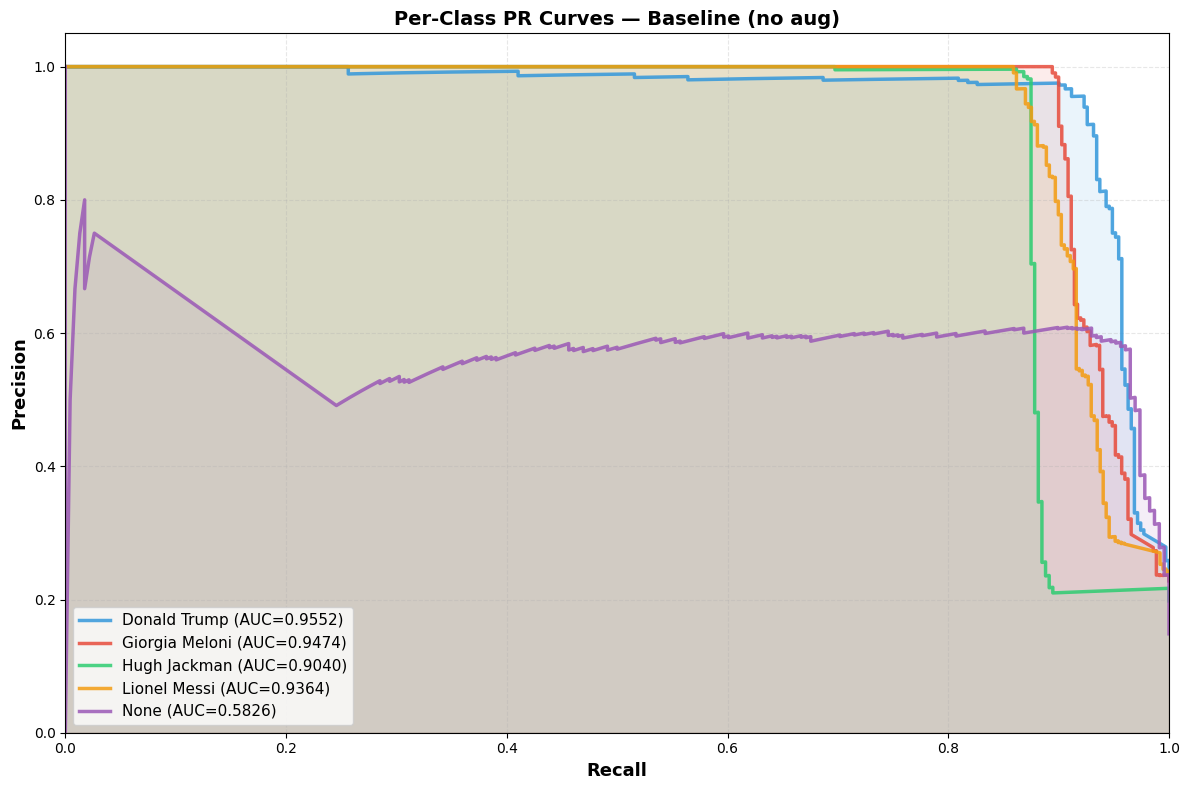

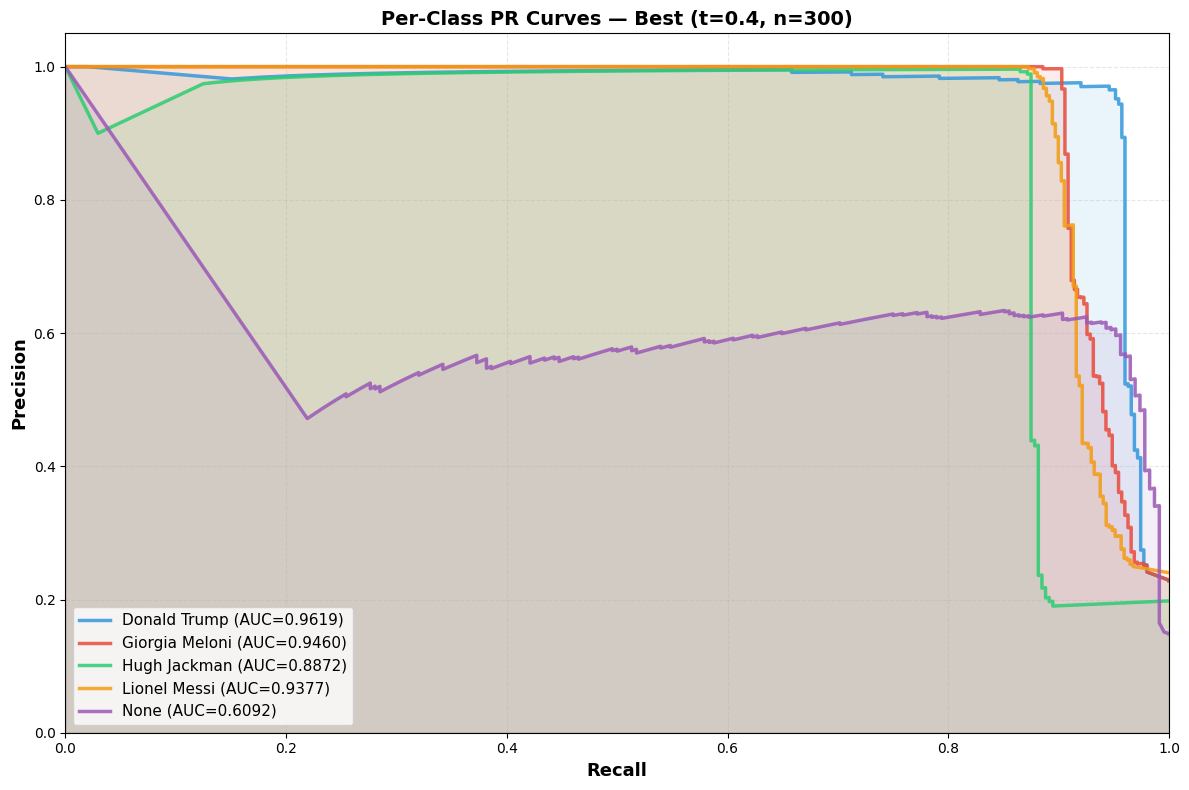

✓ Per-class PR comparison saved


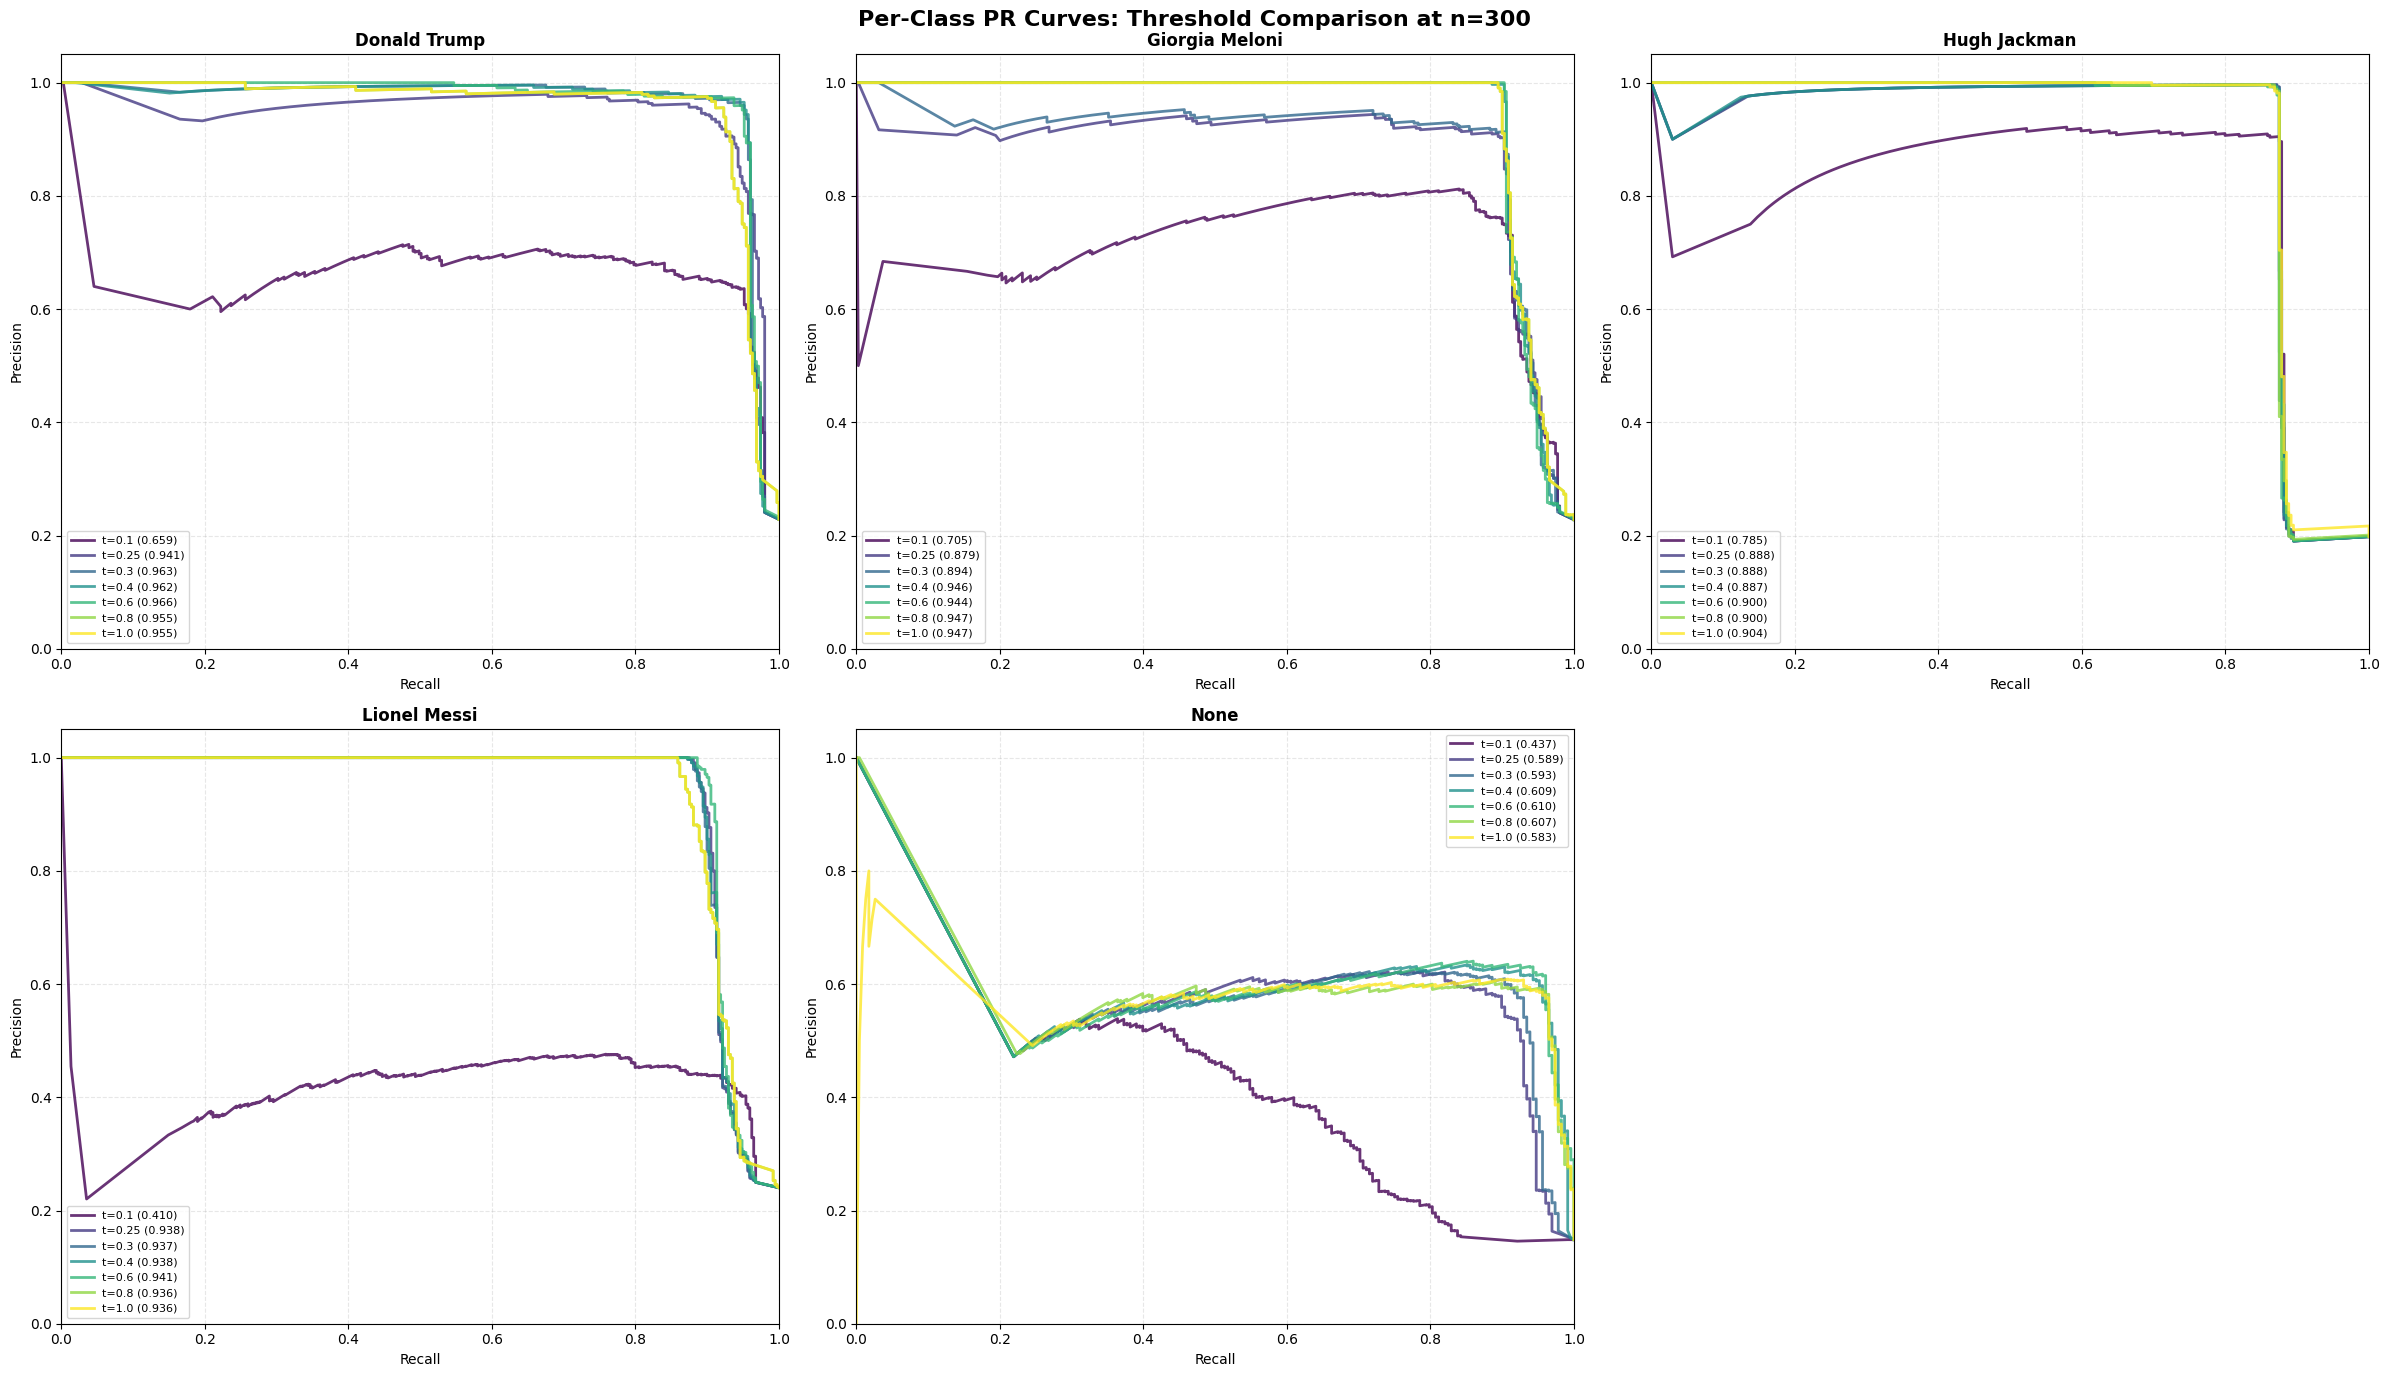

In [14]:
## Per-Class PR Curves: Baseline vs Best Config

print("=" * 100)
print("PER-CLASS PRECISION-RECALL CURVES — BASELINE vs BEST")
print("=" * 100)

# Get baseline and best F-beta config
baseline_iter = next(d for d in iteration_detailed_data if d['sample_size'] == 0)
best_fbeta_idx = results_df['f_beta_macro'].idxmax()
best_iter = iteration_detailed_data[best_fbeta_idx]

configs_to_plot = [
    ("Baseline (no aug)", baseline_iter),
    (f"Best (t={results_df.loc[best_fbeta_idx, 'aug_threshold']}, n={int(results_df.loc[best_fbeta_idx, 'sample_size'])})", best_iter),
]

all_classes = sorted(set(c for d in iteration_detailed_data for c in d.get('class_names', [])))
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for config_name, iter_data in configs_to_plot:
    y_true = iter_data['y_true']
    scores = iter_data['scores']
    class_names = iter_data['class_names']
    
    if y_true is None or not class_names:
        continue
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for class_idx, class_name in enumerate(class_names):
        y_true_binary = y_true[:, class_idx]
        if class_name == 'None':
            y_scores = np.array([1 - max(s.values()) if s else 1.0 for s in scores])
        else:
            y_scores = np.array([s.get(class_name, 0.0) for s in scores])
        
        prec_c, rec_c, _ = precision_recall_curve(y_true_binary, y_scores)
        try:
            pr_auc_val = float(sk_auc(rec_c, prec_c))
        except ValueError:
            pr_auc_val = 0.0
        
        color = colors_palette[class_idx % len(colors_palette)]
        ax.plot(rec_c, prec_c, linewidth=2.5, color=color,
               label=f'{class_name} (AUC={pr_auc_val:.4f})', alpha=0.85)
        ax.fill_between(rec_c, prec_c, alpha=0.1, color=color)
    
    ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
    ax.set_title(f'Per-Class PR Curves — {config_name}', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    safe_name = config_name.replace(' ', '_').replace('=', '').replace('(', '').replace(')', '')
    plt.savefig(EXPERIMENT_DIR / f"per_class_pr_{safe_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

# ═══════════════════════════════════════════════════════════════
# Per-class comparison across thresholds (at max sample size)
# ═══════════════════════════════════════════════════════════════
max_ss = max(SAMPLE_SIZES)
num_classes = len(all_classes)
fig, axes = plt.subplots(2, (num_classes + 1) // 2, figsize=(8 * ((num_classes + 1) // 2), 14))
fig.suptitle(f"Per-Class PR Curves: Threshold Comparison at n={max_ss}", fontsize=16, fontweight='bold')
axes_flat = np.array(axes).flatten()

cmap = plt.cm.viridis
for class_idx, class_name in enumerate(all_classes):
    if class_idx >= len(axes_flat):
        break
    ax = axes_flat[class_idx]
    
    for t_idx, thresh in enumerate(AUGMENTATION_THRESHOLDS):
        matching = [d for d in iteration_detailed_data 
                   if d['aug_threshold'] == thresh and d['sample_size'] == max_ss]
        if not matching:
            continue
        iter_data = matching[0]
        y_true = iter_data['y_true']
        scores = iter_data['scores']
        class_names = iter_data['class_names']
        
        if y_true is None or class_name not in class_names:
            continue
        
        cidx = class_names.index(class_name)
        y_true_binary = y_true[:, cidx]
        if class_name == 'None':
            y_scores = np.array([1 - max(s.values()) if s else 1.0 for s in scores])
        else:
            y_scores = np.array([s.get(class_name, 0.0) for s in scores])
        
        prec_c, rec_c, _ = precision_recall_curve(y_true_binary, y_scores)
        try:
            auc_val = float(sk_auc(rec_c, prec_c))
        except ValueError:
            auc_val = 0.0
        
        color = cmap(t_idx / max(len(AUGMENTATION_THRESHOLDS) - 1, 1))
        ax.plot(rec_c, prec_c, linewidth=2, color=color,
               label=f't={thresh} ({auc_val:.3f})', alpha=0.8)
    
    ax.set_title(class_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')

for idx in range(num_classes, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / f"per_class_pr_threshold_comparison_n{max_ss}.png", dpi=150, bbox_inches='tight')
print(f"✓ Per-class PR comparison saved")
plt.show()

CONFUSION MATRICES
✓ Confusion matrices saved: /app/image_outputs/blind_augmentation_exp_20260221_235304/confusion_matrices.png


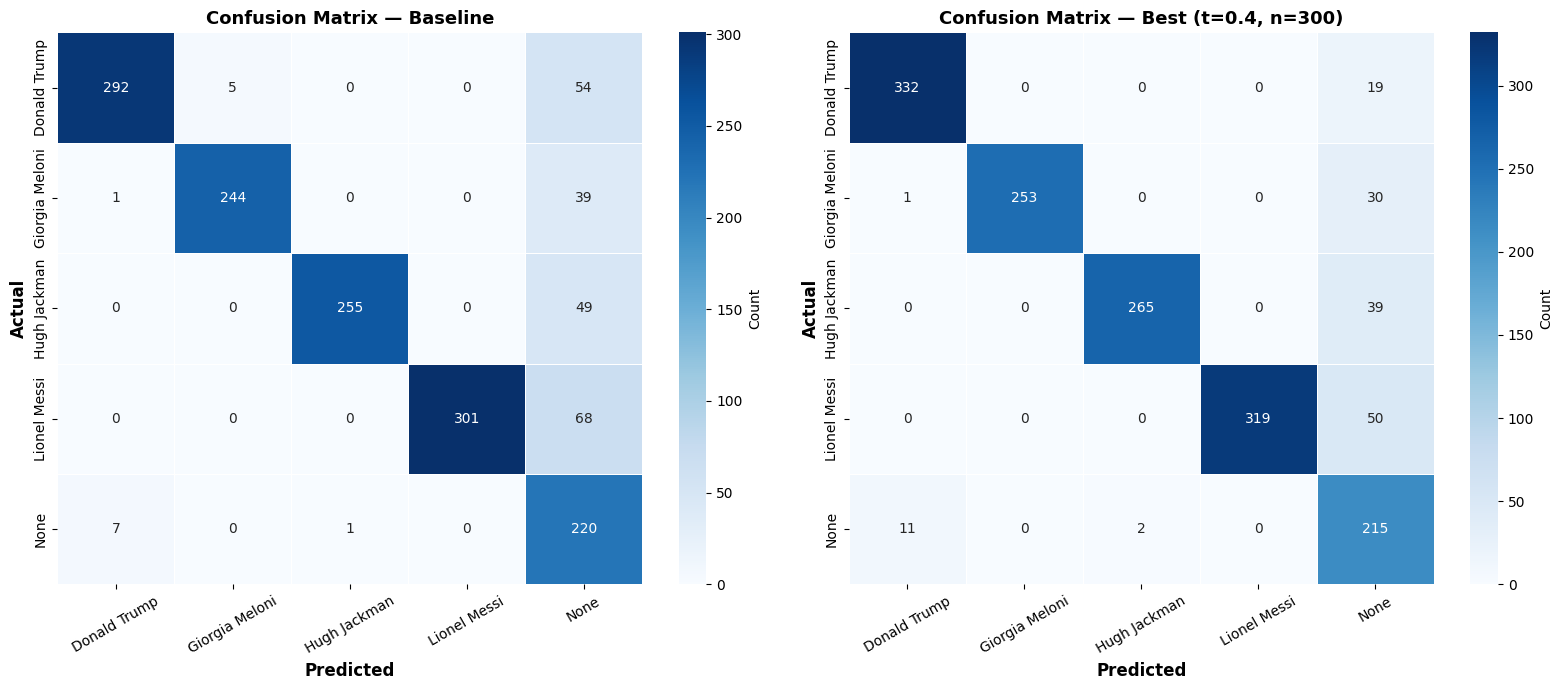

In [15]:
## Confusion Matrices — Baseline vs Best Configuration

print("=" * 100)
print("CONFUSION MATRICES")
print("=" * 100)

baseline_iter = next(d for d in iteration_detailed_data if d['sample_size'] == 0)
best_fbeta_idx = results_df['f_beta_macro'].idxmax()
best_iter = iteration_detailed_data[best_fbeta_idx]

configs_cm = [
    ("Baseline", baseline_iter),
    (f"Best (t={results_df.loc[best_fbeta_idx, 'aug_threshold']}, n={int(results_df.loc[best_fbeta_idx, 'sample_size'])})", best_iter),
]

fig, axes = plt.subplots(1, len(configs_cm), figsize=(8 * len(configs_cm), 7))
if len(configs_cm) == 1:
    axes = [axes]

for ax, (config_name, iter_data) in zip(axes, configs_cm):
    gt = iter_data['ground_truth']
    preds = iter_data['predictions']
    
    # Convert multilabel to single label (take first label or 'None')
    y_true_single = [labels[0] if labels else 'None' for labels in gt]
    y_pred_single = [labels[0] if labels else 'None' for labels in preds]
    
    labels_sorted = sorted(set(y_true_single) | set(y_pred_single))
    cm = confusion_matrix(y_true_single, y_pred_single, labels=labels_sorted)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels_sorted, yticklabels=labels_sorted,
                linewidths=0.5, cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_title(f'Confusion Matrix — {config_name}', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
cm_path = EXPERIMENT_DIR / "confusion_matrices.png"
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
print(f"✓ Confusion matrices saved: {cm_path}")
plt.show()

AUGMENTATION IMPACT ANALYSIS — DELTA FROM BASELINE

Baseline values:
  Accuracy: 0.8516
  F-β(0.4): 0.8838
  Precision: 0.8962
  Recall: 0.8646
  MCC: 0.8402
  Kappa: 0.8184

✓ Delta heatmaps saved: /app/image_outputs/blind_augmentation_exp_20260221_235304/delta_from_baseline.png


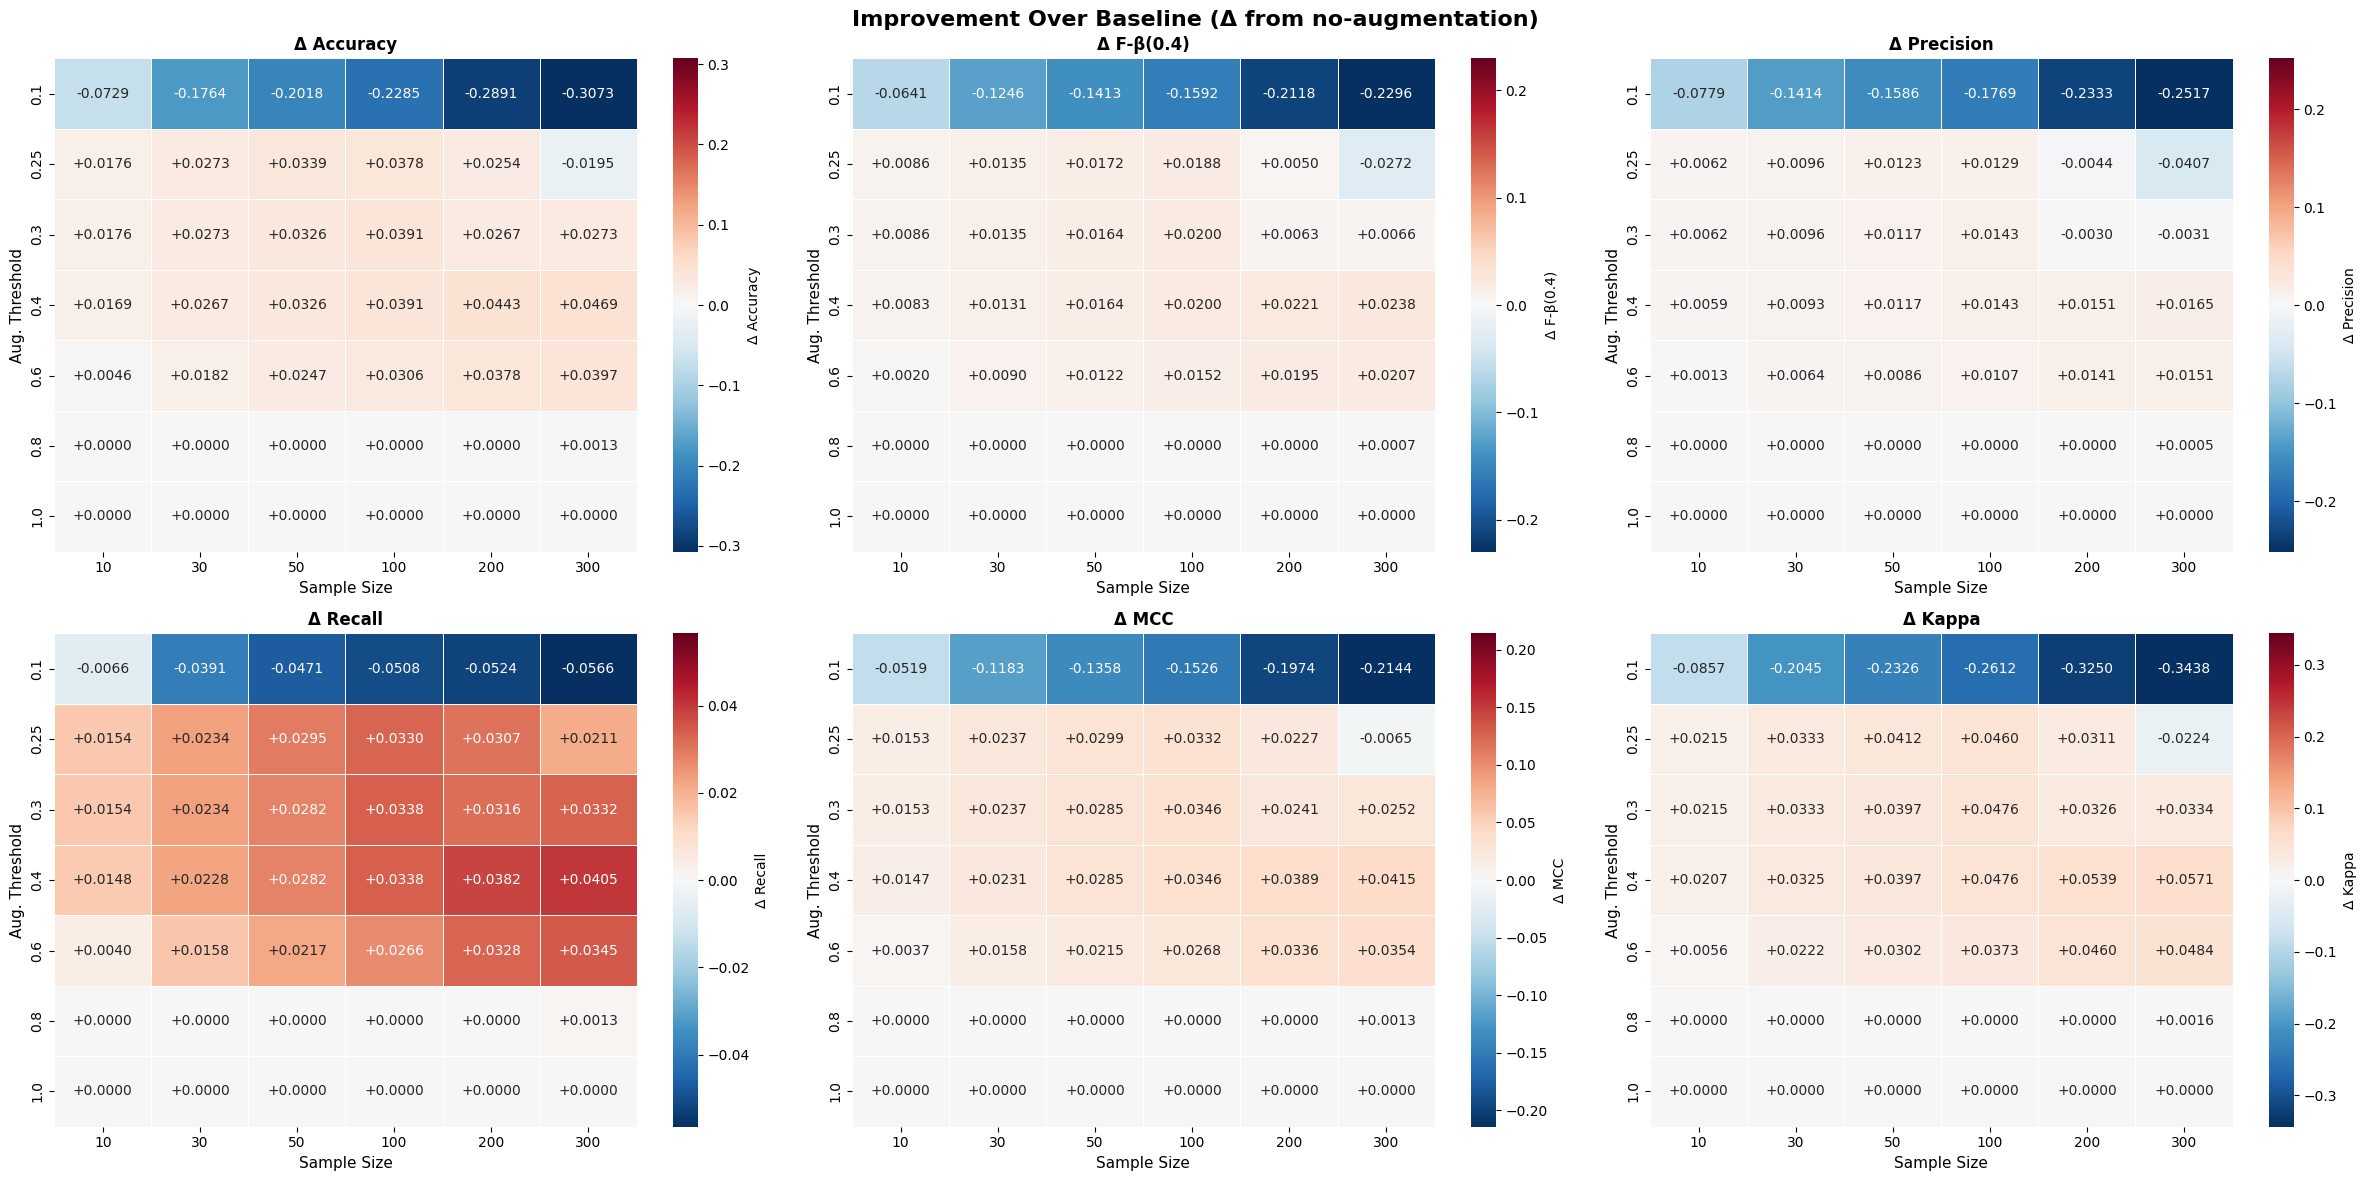


────────────────────────────────────────────────────────────────────────────────────────────────────
TOP 5 IMPROVEMENTS (by F-β):
  t=0.4, n=300: Δ_F-β=+0.0238, Δ_Acc=+0.0469, Δ_MCC=+0.0415
  t=0.4, n=200: Δ_F-β=+0.0221, Δ_Acc=+0.0443, Δ_MCC=+0.0389
  t=0.6, n=300: Δ_F-β=+0.0207, Δ_Acc=+0.0397, Δ_MCC=+0.0354
  t=0.3, n=100: Δ_F-β=+0.0200, Δ_Acc=+0.0391, Δ_MCC=+0.0346
  t=0.4, n=100: Δ_F-β=+0.0200, Δ_Acc=+0.0391, Δ_MCC=+0.0346

TOP 5 DEGRADATIONS (by F-β):
  t=0.1, n=300: Δ_F-β=-0.2296, Δ_Acc=-0.3073, Δ_MCC=-0.2144
  t=0.1, n=200: Δ_F-β=-0.2118, Δ_Acc=-0.2891, Δ_MCC=-0.1974
  t=0.1, n=100: Δ_F-β=-0.1592, Δ_Acc=-0.2285, Δ_MCC=-0.1526
  t=0.1, n=50: Δ_F-β=-0.1413, Δ_Acc=-0.2018, Δ_MCC=-0.1358
  t=0.1, n=30: Δ_F-β=-0.1246, Δ_Acc=-0.1764, Δ_MCC=-0.1183


In [16]:
## Augmentation Impact Analysis — Delta from Baseline

print("=" * 100)
print("AUGMENTATION IMPACT ANALYSIS — DELTA FROM BASELINE")
print("=" * 100)

baseline_row = results_df[results_df['sample_size'] == 0].iloc[0]

# Compute deltas
delta_metrics = ['subset_accuracy', 'f_beta_macro', 'precision_macro', 'recall_macro', 'mcc_macro', 'kappa']
delta_labels = ['Accuracy', f'F-β({F1_BETA})', 'Precision', 'Recall', 'MCC', 'Kappa']

print(f"\nBaseline values:")
for mk, ml in zip(delta_metrics, delta_labels):
    print(f"  {ml}: {baseline_row[mk]:.4f}")

# Build delta DataFrame for non-zero sample sizes
augmented_df = results_df[results_df['sample_size'] > 0].copy()
for mk, ml in zip(delta_metrics, delta_labels):
    augmented_df[f'delta_{ml}'] = augmented_df[mk] - baseline_row[mk]

# Delta heatmaps
fig, axes = plt.subplots(2, 3, figsize=(24, 12))
fig.suptitle("Improvement Over Baseline (Δ from no-augmentation)", fontsize=16, fontweight='bold')

for ax, (mk, ml) in zip(axes.flat, zip(delta_metrics, delta_labels)):
    pivot = augmented_df.pivot_table(index='aug_threshold', columns='sample_size', values=f'delta_{ml}', aggfunc='first')
    
    max_abs = max(abs(pivot.values.min()), abs(pivot.values.max()), 0.001)
    sns.heatmap(pivot, annot=True, fmt='+.4f', cmap='RdBu_r', ax=ax,
                center=0, vmin=-max_abs, vmax=max_abs,
                linewidths=0.5, cbar_kws={'label': f'Δ {ml}'})
    ax.set_title(f'Δ {ml}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Size', fontsize=11)
    ax.set_ylabel('Aug. Threshold', fontsize=11)

plt.tight_layout()
delta_path = EXPERIMENT_DIR / "delta_from_baseline.png"
plt.savefig(delta_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Delta heatmaps saved: {delta_path}")
plt.show()

# Print top improvements and degradations
print(f"\n{'─' * 100}")
print("TOP 5 IMPROVEMENTS (by F-β):")
top_improve = augmented_df.nlargest(5, f'delta_F-β({F1_BETA})')
for _, row in top_improve.iterrows():
    print(f"  t={row['aug_threshold']}, n={int(row['sample_size'])}: "
          f"Δ_F-β={row[f'delta_F-β({F1_BETA})']:+.4f}, "
          f"Δ_Acc={row['delta_Accuracy']:+.4f}, "
          f"Δ_MCC={row['delta_MCC']:+.4f}")

print(f"\nTOP 5 DEGRADATIONS (by F-β):")
top_degrade = augmented_df.nsmallest(5, f'delta_F-β({F1_BETA})')
for _, row in top_degrade.iterrows():
    print(f"  t={row['aug_threshold']}, n={int(row['sample_size'])}: "
          f"Δ_F-β={row[f'delta_F-β({F1_BETA})']:+.4f}, "
          f"Δ_Acc={row['delta_Accuracy']:+.4f}, "
          f"Δ_MCC={row['delta_MCC']:+.4f}")

REFERENCE DB SIZE vs PERFORMANCE
✓ Ref DB size analysis saved: /app/image_outputs/blind_augmentation_exp_20260221_235304/refdb_size_analysis.png


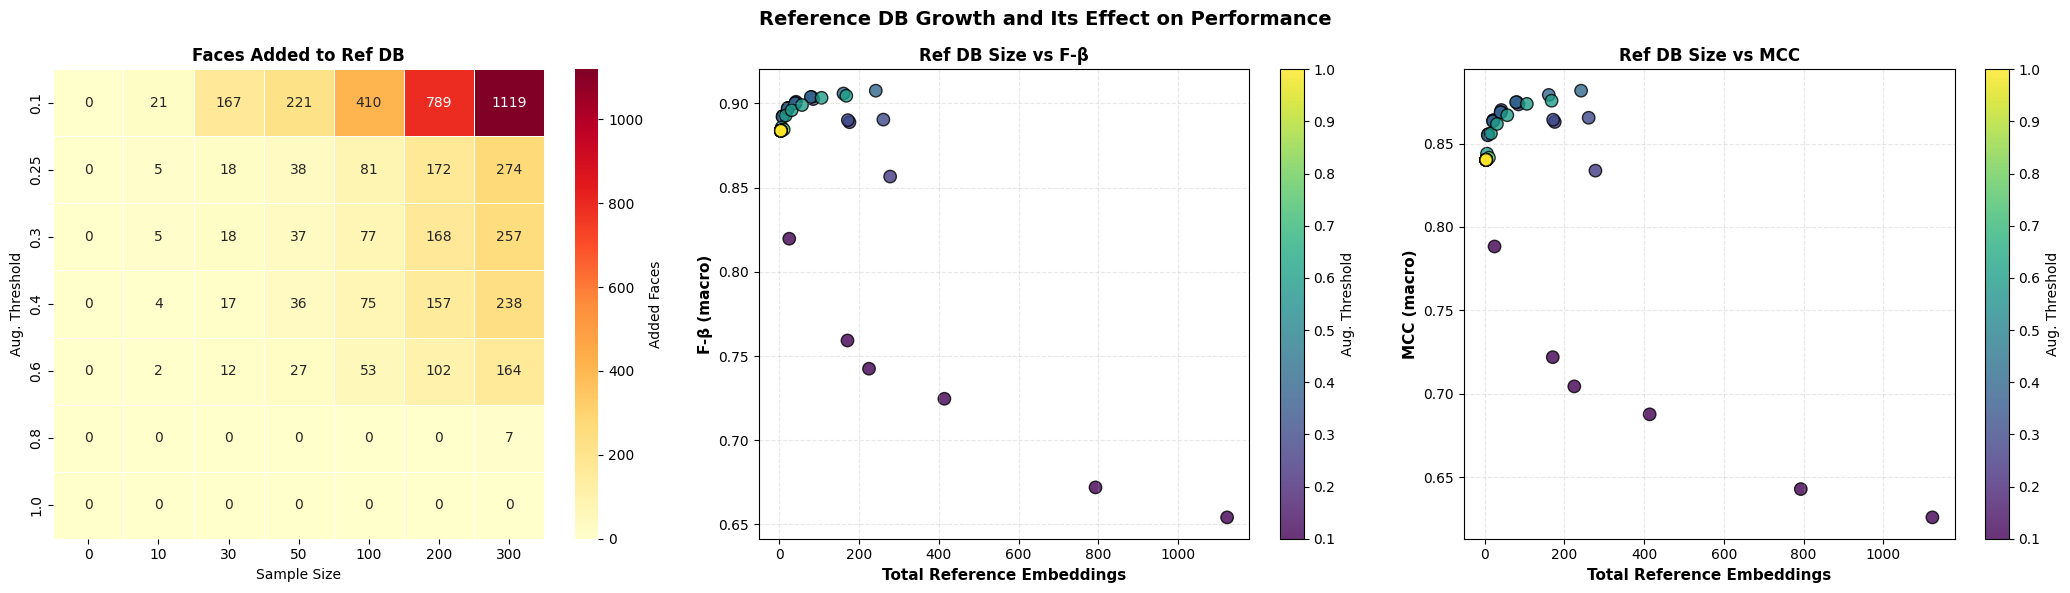

In [17]:
## Reference DB Size Analysis — How augmentation scales

print("=" * 100)
print("REFERENCE DB SIZE vs PERFORMANCE")
print("=" * 100)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("Reference DB Growth and Its Effect on Performance", fontsize=14, fontweight='bold')

# Plot 1: Added faces heatmap
ax = axes[0]
pivot_added = results_df.pivot_table(index='aug_threshold', columns='sample_size', values='added_faces', aggfunc='first')
sns.heatmap(pivot_added, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Added Faces'})
ax.set_title('Faces Added to Ref DB', fontsize=12, fontweight='bold')
ax.set_xlabel('Sample Size'); ax.set_ylabel('Aug. Threshold')

# Plot 2: Ref DB size vs F-beta (scatter)
ax = axes[1]
scatter = ax.scatter(results_df['total_ref_embeddings'], results_df['f_beta_macro'],
                     c=results_df['aug_threshold'], cmap='viridis', s=80, alpha=0.8, edgecolors='k')
plt.colorbar(scatter, ax=ax, label='Aug. Threshold')
ax.set_xlabel('Total Reference Embeddings', fontsize=11, fontweight='bold')
ax.set_ylabel(f'F-β (macro)', fontsize=11, fontweight='bold')
ax.set_title('Ref DB Size vs F-β', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Plot 3: Ref DB size vs MCC (scatter)
ax = axes[2]
scatter = ax.scatter(results_df['total_ref_embeddings'], results_df['mcc_macro'],
                     c=results_df['aug_threshold'], cmap='viridis', s=80, alpha=0.8, edgecolors='k')
plt.colorbar(scatter, ax=ax, label='Aug. Threshold')
ax.set_xlabel('Total Reference Embeddings', fontsize=11, fontweight='bold')
ax.set_ylabel('MCC (macro)', fontsize=11, fontweight='bold')
ax.set_title('Ref DB Size vs MCC', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
refdb_path = EXPERIMENT_DIR / "refdb_size_analysis.png"
plt.savefig(refdb_path, dpi=150, bbox_inches='tight')
print(f"✓ Ref DB size analysis saved: {refdb_path}")
plt.show()

THRESHOLD SENSITIVITY ANALYSIS
✓ Threshold sensitivity saved: /app/image_outputs/blind_augmentation_exp_20260221_235304/threshold_sensitivity.png


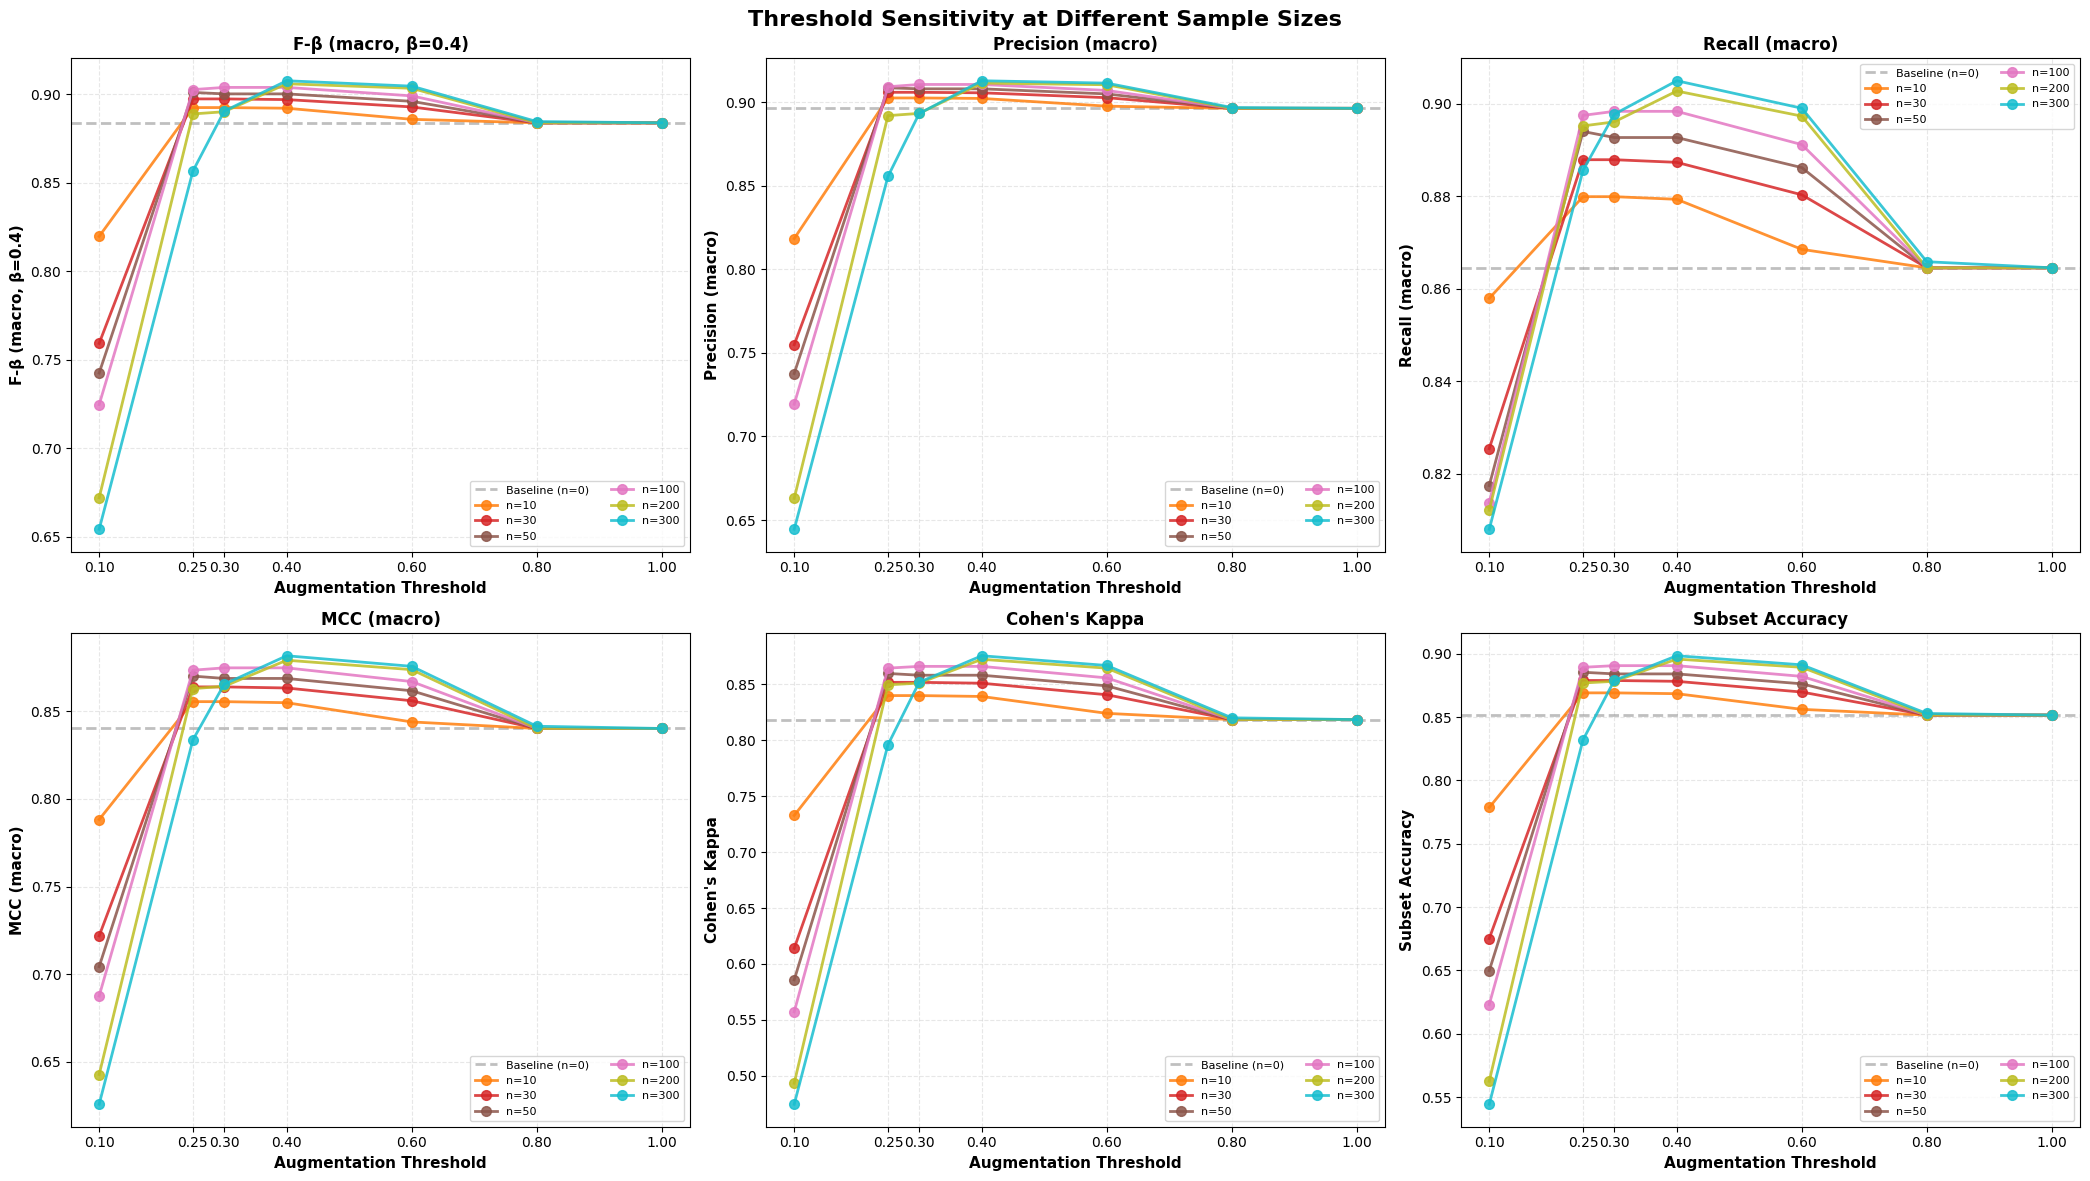

In [18]:
## Threshold Sensitivity Analysis

print("=" * 100)
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 100)

# For each sample size > 0, how does performance change with threshold?
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle("Threshold Sensitivity at Different Sample Sizes", fontsize=16, fontweight='bold')

sensitivity_metrics = [
    ('f_beta_macro', f'F-β (macro, β={F1_BETA})'),
    ('precision_macro', 'Precision (macro)'),
    ('recall_macro', 'Recall (macro)'),
    ('mcc_macro', 'MCC (macro)'),
    ('kappa', "Cohen's Kappa"),
    ('subset_accuracy', 'Subset Accuracy'),
]

sample_colors = plt.cm.tab10(np.linspace(0, 1, len(SAMPLE_SIZES)))

for ax, (mk, ml) in zip(axes.flat, sensitivity_metrics):
    for i, ss in enumerate(SAMPLE_SIZES):
        if ss == 0:
            # Draw horizontal baseline
            baseline_val = results_df[results_df['sample_size'] == 0].iloc[0][mk]
            ax.axhline(y=baseline_val, color='gray', linestyle='--', linewidth=2, alpha=0.5, label=f'Baseline (n=0)')
        else:
            subset = results_df[results_df['sample_size'] == ss].sort_values('aug_threshold')
            ax.plot(subset['aug_threshold'], subset[mk],
                    marker='o', linewidth=2, markersize=7,
                    color=sample_colors[i], label=f'n={ss}', alpha=0.85)
    
    ax.set_xlabel('Augmentation Threshold', fontsize=11, fontweight='bold')
    ax.set_ylabel(ml, fontsize=11, fontweight='bold')
    ax.set_title(ml, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='best', ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(AUGMENTATION_THRESHOLDS)

plt.tight_layout()
sensitivity_path = EXPERIMENT_DIR / "threshold_sensitivity.png"
plt.savefig(sensitivity_path, dpi=150, bbox_inches='tight')
print(f"✓ Threshold sensitivity saved: {sensitivity_path}")
plt.show()

PRECISION-RECALL TRADE-OFF ACROSS THRESHOLDS
✓ Precision-recall trade-off saved: /app/image_outputs/blind_augmentation_exp_20260221_235304/precision_recall_tradeoff.png


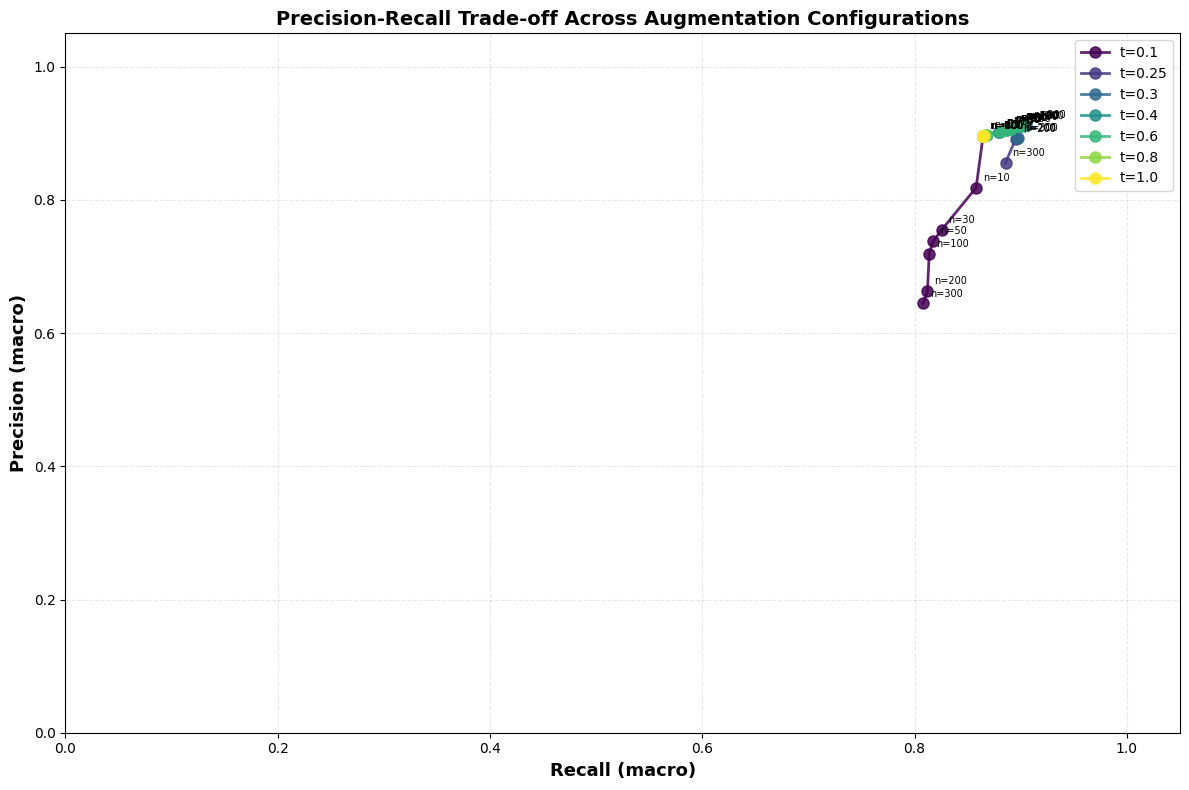

In [19]:
## Precision-Recall Trade-off Analysis

print("=" * 100)
print("PRECISION-RECALL TRADE-OFF ACROSS THRESHOLDS")
print("=" * 100)

fig, ax = plt.subplots(figsize=(12, 8))

cmap = plt.cm.viridis
for i, thresh in enumerate(AUGMENTATION_THRESHOLDS):
    subset = results_df[results_df['aug_threshold'] == thresh].sort_values('sample_size')
    color = cmap(i / max(len(AUGMENTATION_THRESHOLDS) - 1, 1))
    
    ax.plot(subset['recall_macro'], subset['precision_macro'],
            marker='o', linewidth=2, markersize=8,
            color=color, label=f't={thresh}', alpha=0.85)
    
    # Annotate each point with sample size
    for _, row in subset.iterrows():
        ax.annotate(f"n={int(row['sample_size'])}", 
                   (row['recall_macro'], row['precision_macro']),
                   fontsize=7, textcoords="offset points", xytext=(5, 5))

ax.set_xlabel('Recall (macro)', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision (macro)', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall Trade-off Across Augmentation Configurations', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([0, 1.05]); ax.set_ylim([0, 1.05])

plt.tight_layout()
tradeoff_path = EXPERIMENT_DIR / "precision_recall_tradeoff.png"
plt.savefig(tradeoff_path, dpi=150, bbox_inches='tight')
print(f"✓ Precision-recall trade-off saved: {tradeoff_path}")
plt.show()

# Experiment Summary & Recommendations

Final summary of findings across all (threshold × sample_size) configurations.

In [20]:
## Final Summary — Key Findings

print("=" * 120)
print("EXPERIMENT SUMMARY — BLIND REFERENCE DB AUGMENTATION")
print("=" * 120)

baseline_row = results_df[results_df['sample_size'] == 0].iloc[0]

print(f"\n📊 Experiment Configuration:")
print(f"  Augmentation thresholds tested: {AUGMENTATION_THRESHOLDS}")
print(f"  Sample sizes tested: {SAMPLE_SIZES}")
print(f"  Total configurations evaluated: {len(results_df)}")
print(f"  Face identification threshold: {FACE_IDENTIFICATION_THRESHOLD}")
print(f"  F-beta parameter: {F1_BETA}")

print(f"\n{'─' * 120}")
print(f"📏 BASELINE PERFORMANCE (no augmentation):")
print(f"  Subset Accuracy: {baseline_row['subset_accuracy']:.4f}")
print(f"  F-β (macro):     {baseline_row['f_beta_macro']:.4f}")
print(f"  Precision (macro):{baseline_row['precision_macro']:.4f}")
print(f"  Recall (macro):   {baseline_row['recall_macro']:.4f}")
print(f"  MCC (macro):      {baseline_row['mcc_macro']:.4f}")
print(f"  Cohen's Kappa:    {baseline_row['kappa']:.4f}")
print(f"  PR-AUC (macro):   {baseline_row['macro_pr_auc']:.4f}")
print(f"  ROC-AUC (macro):  {baseline_row['macro_roc_auc']:.4f}")

# Best configurations per metric
print(f"\n{'─' * 120}")
print("🏆 BEST CONFIGURATIONS PER METRIC:")
key_metrics = [
    ('subset_accuracy', 'Subset Accuracy'),
    ('f_beta_macro', f'F-β (macro)'),
    ('precision_macro', 'Precision (macro)'),
    ('recall_macro', 'Recall (macro)'),
    ('mcc_macro', 'MCC (macro)'),
    ('kappa', "Cohen's Kappa"),
    ('macro_pr_auc', 'PR-AUC (macro)'),
    ('macro_roc_auc', 'ROC-AUC (macro)'),
]

for mk, ml in key_metrics:
    best_idx = results_df[mk].idxmax()
    best_row = results_df.loc[best_idx]
    delta = best_row[mk] - baseline_row[mk]
    delta_str = f"({delta:+.4f} vs baseline)" if delta != 0 else "(= baseline)"
    print(f"  {ml:25s}: {best_row[mk]:.4f} {delta_str}  [t={best_row['aug_threshold']}, n={int(best_row['sample_size'])}]")

# Overall best config (by F-beta)
best_idx = results_df['f_beta_macro'].idxmax()
best = results_df.loc[best_idx]
print(f"\n{'─' * 120}")
print(f"⭐ RECOMMENDED CONFIGURATION (best F-β macro):")
print(f"  Augmentation threshold: {best['aug_threshold']}")
print(f"  Sample size:            {int(best['sample_size'])}")
print(f"  Faces added:            {int(best['added_faces'])}")
print(f"  Total ref embeddings:   {int(best['total_ref_embeddings'])}")
print(f"\n  Performance:")
print(f"    F-β (macro):     {best['f_beta_macro']:.4f} ({best['f_beta_macro'] - baseline_row['f_beta_macro']:+.4f})")
print(f"    Accuracy:        {best['subset_accuracy']:.4f} ({best['subset_accuracy'] - baseline_row['subset_accuracy']:+.4f})")
print(f"    Precision (macro):{best['precision_macro']:.4f} ({best['precision_macro'] - baseline_row['precision_macro']:+.4f})")
print(f"    Recall (macro):  {best['recall_macro']:.4f} ({best['recall_macro'] - baseline_row['recall_macro']:+.4f})")
print(f"    MCC (macro):     {best['mcc_macro']:.4f} ({best['mcc_macro'] - baseline_row['mcc_macro']:+.4f})")
print(f"    Cohen's Kappa:   {best['kappa']:.4f} ({best['kappa'] - baseline_row['kappa']:+.4f})")

# Summary of augmentation effectiveness
print(f"\n{'─' * 120}")
print("📈 AUGMENTATION EFFECTIVENESS SUMMARY:")
augmented = results_df[results_df['sample_size'] > 0]
improved_count = (augmented['f_beta_macro'] > baseline_row['f_beta_macro']).sum()
degraded_count = (augmented['f_beta_macro'] < baseline_row['f_beta_macro']).sum()
tied_count = (augmented['f_beta_macro'] == baseline_row['f_beta_macro']).sum()
total_aug = len(augmented)
print(f"  Configs that improved F-β:  {improved_count}/{total_aug} ({improved_count/total_aug*100:.1f}%)")
print(f"  Configs that degraded F-β:  {degraded_count}/{total_aug} ({degraded_count/total_aug*100:.1f}%)")
print(f"  Configs with no change:     {tied_count}/{total_aug} ({tied_count/total_aug*100:.1f}%)")

if improved_count > 0:
    avg_improvement = augmented.loc[augmented['f_beta_macro'] > baseline_row['f_beta_macro'], 'f_beta_macro'].mean() - baseline_row['f_beta_macro']
    print(f"  Average improvement when improved: {avg_improvement:+.4f}")
if degraded_count > 0:
    avg_degradation = augmented.loc[augmented['f_beta_macro'] < baseline_row['f_beta_macro'], 'f_beta_macro'].mean() - baseline_row['f_beta_macro']
    print(f"  Average degradation when degraded: {avg_degradation:+.4f}")

print(f"\n{'=' * 120}")
print(f"✓ Experiment complete. All results saved to: {EXPERIMENT_DIR}")
print(f"{'=' * 120}")

EXPERIMENT SUMMARY — BLIND REFERENCE DB AUGMENTATION

📊 Experiment Configuration:
  Augmentation thresholds tested: [0.1, 0.25, 0.3, 0.4, 0.6, 0.8, 1.0]
  Sample sizes tested: [0, 10, 30, 50, 100, 200, 300]
  Total configurations evaluated: 49
  Face identification threshold: 0.3
  F-beta parameter: 0.4

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📏 BASELINE PERFORMANCE (no augmentation):
  Subset Accuracy: 0.8516
  F-β (macro):     0.8838
  Precision (macro):0.8962
  Recall (macro):   0.8646
  MCC (macro):      0.8402
  Cohen's Kappa:    0.8184
  PR-AUC (macro):   0.8651
  ROC-AUC (macro):  0.9398

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
🏆 BEST CONFIGURATIONS PER METRIC:
  Subset Accuracy          : 0.8984 (+0.0469 vs baseline)  [t=0.4, n=300]
  F-β (macro)              : 0.9075 (+0.0238 vs baseline)  [t=0.4, n=300]
  Precision (

In [21]:
## Save Full Results to CSV

# Save complete results
csv_path = EXPERIMENT_DIR / "experiment_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"✓ Full results saved to: {csv_path}")

# Save experiment configuration
config = {
    "augmentation_thresholds": AUGMENTATION_THRESHOLDS,
    "sample_sizes": SAMPLE_SIZES,
    "face_identification_threshold": FACE_IDENTIFICATION_THRESHOLD,
    "f_beta": F1_BETA,
    "fixed_recall_level": FIXED_RECALL_LEVEL,
    "fixed_precision_level": FIXED_PRECISION_LEVEL,
    "random_seed": RANDOM_SEED,
    "total_combinations": len(results_df),
    "trainset_path": str(TRAINSET_PATH),
    "trainset_size": len(train_items),
}
config_path = EXPERIMENT_DIR / "experiment_config.json"
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Configuration saved to: {config_path}")

# Print saved files
print(f"\n📁 Output directory: {EXPERIMENT_DIR}")
saved_files = sorted(EXPERIMENT_DIR.glob('*'))
for f in saved_files:
    print(f"  {f.name}")

✓ Full results saved to: /app/image_outputs/blind_augmentation_exp_20260221_235304/experiment_results.csv
✓ Configuration saved to: /app/image_outputs/blind_augmentation_exp_20260221_235304/experiment_config.json

📁 Output directory: /app/image_outputs/blind_augmentation_exp_20260221_235304
  confusion_matrices.png
  delta_from_baseline.png
  experiment_config.json
  experiment_results.csv
  macro_pr_curves_comparison.png
  macro_roc_curves_comparison.png
  metric_heatmaps_threshold_x_samplesize.png
  metrics_vs_samplesize_by_threshold.png
  metrics_vs_threshold_by_samplesize.png
  per_class_heatmap_n300.png
  per_class_pr_Baseline_no_aug.png
  per_class_pr_Best_t0.4,_n300.png
  per_class_pr_threshold_comparison_n300.png
  precision_recall_tradeoff.png
  refdb_size_analysis.png
  threshold_sensitivity.png
